# **📦 ETAPA 1 — COLETA DE DADOS**

In [36]:
#@title 🔵 Configuração do Ambiente e Importação de Bibliotecas

# ╔═══════════════════════════════════════════════════════════════════╗
# ║ Instala e importa as bibliotecas necessárias, monta o Google Drive║
# ║ e realiza o download do dataset do Kaggle para análise.           ║
# ╚═══════════════════════════════════════════════════════════════════╝

# 1.1 Importar bibliotecas essenciais
import os
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import seaborn as sns

# 1.2 Importar bibliotecas de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1.3 Montar Google Drive (silencioso)
from google.colab import drive
import warnings
warnings.filterwarnings('ignore')
drive.mount('/content/drive', force_remount=False)

# 1.4 Configurar Kaggle (silencioso)
!mkdir -p ~/.kaggle 2>/dev/null
shutil.copy('/content/drive/MyDrive/crisp_ecommerce/kaggle.json', '/root/.kaggle/kaggle.json')
!chmod 600 /root/.kaggle/kaggle.json 2>/dev/null

# 1.5 Criar pasta e baixar dataset (se necessário)
os.makedirs('/content/drive/MyDrive/crisp_ecommerce/olist_data', exist_ok=True)
caminho_base = '/content/drive/MyDrive/crisp_ecommerce/olist_data'
arquivo_teste = f'{caminho_base}/olist_orders_dataset.csv'

if not os.path.exists(arquivo_teste):
    !kaggle datasets download -d olistbr/brazilian-ecommerce -p {caminho_base} --unzip --quiet 2>/dev/null

# 1.6 Limpar saída e mostrar apenas as tabelas
clear_output()

dataset_nome = "Brazilian E-commerce (Olist)"
local_dataset = caminho_base  # já definido antes no seu código

arquivos = sorted([f for f in os.listdir(caminho_base) if f.endswith('.csv')])

print(f"📦 {dataset_nome}")
print(f"   • Local: {local_dataset}\n")

print(f"📂 {len(arquivos)} tabelas disponíveis no dataset:")
for arq in arquivos:
    print(f"   • {arq}")



📦 Brazilian E-commerce (Olist)
   • Local: /content/drive/MyDrive/crisp_ecommerce/olist_data

📂 9 tabelas disponíveis no dataset:
   • olist_customers_dataset.csv
   • olist_geolocation_dataset.csv
   • olist_order_items_dataset.csv
   • olist_order_payments_dataset.csv
   • olist_order_reviews_dataset.csv
   • olist_orders_dataset.csv
   • olist_products_dataset.csv
   • olist_sellers_dataset.csv
   • product_category_name_translation.csv


In [37]:
#@title 🔵 Configurações Globais do Projeto

# ╔════════════════════════════════════════════════════════╗
# ║ Configurar parâmetros e visualização padronizada       ║
# ╚════════════════════════════════════════════════════════╝

# CAMINHOS
CAMINHO_DADOS = '/content/drive/MyDrive/crisp_ecommerce/olist_data'

# PARÂMETROS DE MODELAGEM
TEST_SIZE = 0.25        # 25% dos dados para teste
RANDOM_STATE = 42       # Garante reprodutibilidade

# HIPERPARÂMETROS - RANDOM FOREST
RF_N_ESTIMATORS = 100
RF_MAX_DEPTH = 15
RF_MIN_SAMPLES_SPLIT = 5

# HIPERPARÂMETROS - GRADIENT BOOSTING
GB_N_ESTIMATORS = 100
GB_LEARNING_RATE = 0.1
GB_MAX_DEPTH = 5

print("✅ Parâmetros definidos")


#FUNÇÕES AUXILIARES: VISUALIZAÇÃO PADRONIZADA
def estilo_tabela(df, titulo, cor_header='#AED6F1', cor_texto='#0B5345'):
    """
    Aplica estilo padrão em tabelas.

    Args:
        df: DataFrame a estilizar
        titulo: Título da tabela
        cor_header: Cor do cabeçalho (padrão: azul claro)
        cor_texto: Cor do texto do cabeçalho (padrão: verde escuro)

    Returns:
        DataFrame estilizado
    """
    return df.style.set_table_styles([
        {'selector': 'th', 'props': [
            ('background-color', cor_header),
            ('color', cor_texto),
            ('font-weight', 'bold'),
            ('padding', '8px'),
            ('text-align', 'center')
        ]},
        {'selector': 'td', 'props': [
            ('background-color', '#FDFEFE'),
            ('color', '#1C2833'),
            ('padding', '8px'),
            ('border', '1px solid #D6EAF8')
        ]},
        {'selector': 'tr:nth-child(even)', 'props': [
            ('background-color', '#EBF5FB')
        ]},
        {'selector': 'caption', 'props': [
            ('caption-side', 'top'),
            ('font-size', '16px'),
            ('font-weight', 'bold'),
            ('color', cor_texto),
            ('background-color', cor_header),
            ('padding', '6px'),
            ('border', f'1px solid {cor_header}')
        ]}
    ]).set_properties(**{'text-align': 'center'}).set_caption(titulo)

print("✅ Funções auxiliares carregadas")

✅ Parâmetros definidos
✅ Funções auxiliares carregadas


# **🔍 ETAPA 2 — ENTENDIMENTO DOS DADOS**

In [38]:
#@title 🔵 Verificar variáveis disponíveis nas tabelas

# ╔═══════════════════════════════════════════════════════════════════╗
# ║ Este bloco carrega as tabelas necessárias e mostra suas           ║
# ║ colunas, ajudando a entender a estrutura dos dados.               ║
# ╚═══════════════════════════════════════════════════════════════════╝

# Ler as tabelas
customers = pd.read_csv(f'{CAMINHO_DADOS}/olist_customers_dataset.csv')
orders = pd.read_csv(f'{CAMINHO_DADOS}/olist_orders_dataset.csv')
order_items = pd.read_csv(f'{CAMINHO_DADOS}/olist_order_items_dataset.csv')
products = pd.read_csv(f'{CAMINHO_DADOS}/olist_products_dataset.csv')
sellers = pd.read_csv(f'{CAMINHO_DADOS}/olist_sellers_dataset.csv')

# Listar colunas disponíveis
print("🔹 Colunas da tabela customers:")
print(customers.columns.tolist())

print("\n🔹 Colunas da tabela orders:")
print(orders.columns.tolist())

print("\n🔹 Colunas da tabela order_items:")
print(order_items.columns.tolist())

print("\n🔹 Colunas da tabela products:")
print(products.columns.tolist())

print("\n🔹 Colunas da tabela sellers:")
print(sellers.columns.tolist())

🔹 Colunas da tabela customers:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

🔹 Colunas da tabela orders:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

🔹 Colunas da tabela order_items:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

🔹 Colunas da tabela products:
['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

🔹 Colunas da tabela sellers:
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']


In [39]:
#@title 🔵 Tabela de clientes

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ Este bloco carrega e exibe o DataFrame da tabela `clientes`, renomeia        ║
# ║ colunas, apresenta a análise de valores nulos e permite visualizar cidades   ║
# ║ e estados, com opção de filtrar por estado ou visualizar o total geral.      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Carregar clientes e renomear colunas
customers = pd.read_csv(f'{CAMINHO_DADOS}/olist_customers_dataset.csv')
customers = customers.rename(columns={
    'customer_id': 'id_cliente',
    'customer_unique_id': 'id_cliente_unico',
    'customer_zip_code_prefix': 'cep_cliente',
    'customer_city': 'cidade_cliente',
    'customer_state': 'estado_cliente'
})

# Visualização da tabela clientes
n_linhas = 5
clientes_head = customers.head(n_linhas).copy()
clientes_head.index = range(1, len(clientes_head) + 1)

display(estilo_tabela(clientes_head, "🔍 Visualização do DataFrame `clientes`"))

# Espaço entre as seções
display(HTML("<div style='margin: 30px 0;'></div>"))

# Filtro interativo de cidades por estado
opcoes_estado = ['Nenhum', 'Todos'] + sorted(customers['estado_cliente'].dropna().unique())

dropdown_estado = widgets.Dropdown(
    options=opcoes_estado,
    description='Estado:',
    value='Nenhum',
    style={'description_width': 'initial'}
)

def mostrar_cidades_por_estado(estado):
    if estado == 'Nenhum':
        display(HTML("<p style='color:gray; font-style:italic;'>Nenhum estado selecionado.</p>"))
        return
    elif estado == 'Todos':
        filtrado = customers[['cidade_cliente', 'estado_cliente']].copy()
    else:
        filtrado = customers[customers['estado_cliente'] == estado][['cidade_cliente', 'estado_cliente']].copy()

    filtrado = filtrado.drop_duplicates().sort_values(by='cidade_cliente')
    filtrado.index = range(1, len(filtrado) + 1)

    # Usar estilo_tabela diretamente
    styled = estilo_tabela(filtrado, f"📍 Cidades do estado: {estado}")

    html_scroll = styled.to_html()
    display(HTML(f"""
    <div style="max-height: 280px; max-width: 800px; overflow: auto; border: 1px solid #ccc; padding: 5px;">
    {html_scroll}
    </div>
    """))

output = widgets.interactive_output(mostrar_cidades_por_estado, {'estado': dropdown_estado})
display(dropdown_estado, output)

,id_cliente,id_cliente_unico,cep_cliente,cidade_cliente,estado_cliente
1,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
2,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
3,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
4,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
5,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


Dropdown(description='Estado:', options=('Nenhum', 'Todos', 'AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'G…

Output()

In [40]:
#@title 🔵 Tabela de pedidos

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ Este bloco carrega o DataFrame `orders`, renomeia colunas, exibe a tabela   ║
# ║ inicial, analisa o período das variáveis de data e apresenta a contagem de  ║
# ║ valores nulos de forma visual e limpa.                                      ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Carregar pedidos e renomear colunas
orders = pd.read_csv(f'{CAMINHO_DADOS}/olist_orders_dataset.csv')
orders = orders.rename(columns={
    'order_id': 'id_pedido',
    'customer_id': 'id_cliente',
    'order_status': 'status_pedido',
    'order_purchase_timestamp': 'data_compra_pedido',
    'order_approved_at': 'data_aprovacao_pedido',
    'order_delivered_carrier_date': 'data_entrega_transportadora',
    'order_delivered_customer_date': 'data_entrega_cliente',
    'order_estimated_delivery_date': 'data_entrega_prevista'
})

# Visualização da tabela orders
n_linhas = 5
orders_head = orders.head(n_linhas).copy()
orders_head.index = range(1, len(orders_head) + 1)

display(estilo_tabela(orders_head, "🔍 Visualização do DataFrame `orders`"))

# Espaço entre as seções
display(HTML("<div style='margin: 30px 0;'></div>"))

# Status únicos dos pedidos
status_unicos = pd.DataFrame(sorted(orders['status_pedido'].unique()), columns=['Status'])
status_unicos = status_unicos.T
status_unicos.columns = range(1, len(status_unicos.columns) + 1)

display(estilo_tabela(status_unicos, "Status únicos dos pedidos"))

# Espaço entre as seções
display(HTML("<div style='margin: 30px 0;'></div>"))

# Colunas de datas — período mínimo e máximo
colunas_datas = [
    'data_compra_pedido',
    'data_aprovacao_pedido',
    'data_entrega_transportadora',
    'data_entrega_cliente',
    'data_entrega_prevista'
]

orders[colunas_datas] = orders[colunas_datas].apply(pd.to_datetime, errors='coerce')

periodo_datas = orders[colunas_datas].agg(['min', 'max']).transpose()
periodo_datas['min'] = periodo_datas['min'].dt.strftime('%m/%y')
periodo_datas['max'] = periodo_datas['max'].dt.strftime('%m/%y')
periodo_datas = periodo_datas.rename(columns={'min': 'Menor', 'max': 'Maior'}).reset_index().rename(columns={'index': 'Variável'})
periodo_datas.index = range(1, len(periodo_datas) + 1)

display(estilo_tabela(periodo_datas, "Período de datas em cada coluna"))

,id_pedido,id_cliente,status_pedido,data_compra_pedido,data_aprovacao_pedido,data_entrega_transportadora,data_entrega_cliente,data_entrega_prevista
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
2,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
3,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
4,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
5,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,1,2,3,4,5,6,7,8
Status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable


,Variável,Menor,Maior
1,data_compra_pedido,09/16,10/18
2,data_aprovacao_pedido,09/16,09/18
3,data_entrega_transportadora,10/16,09/18
4,data_entrega_cliente,10/16,10/18
5,data_entrega_prevista,09/16,11/18


In [41]:
#@title 🔵 Tabela de itens dos pedidos (order_items)

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ Este bloco carrega o DataFrame `order_items`, renomeia colunas, exibe a     ║
# ║ tabela inicial e apresenta a contagem de valores nulos de forma visual.     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Carregar itens dos pedidos e renomear colunas
order_items = pd.read_csv(f'{CAMINHO_DADOS}/olist_order_items_dataset.csv')
order_items = order_items.rename(columns={
    'order_id': 'id_pedido',
    'order_item_id': 'numero_item',
    'product_id': 'id_produto',
    'seller_id': 'id_vendedor',
    'shipping_limit_date': 'data_limite_envio',
    'price': 'preco',
    'freight_value': 'valor_frete'
})

# Visualização da tabela order_items
n_linhas = 5
items_head = order_items.head(n_linhas).copy()
items_head.index = range(1, len(items_head) + 1)

display(estilo_tabela(items_head, "🔍 Visualização do DataFrame `order_items`"))

# Espaço entre as seções
display(HTML("<div style='margin: 30px 0;'></div>"))

# Range de valores nas variáveis numéricas
range_valores = pd.DataFrame({
    'Variável': ['preco', 'valor_frete'],
    'Mínimo': [
        f"R$ {order_items['preco'].min():.2f}",
        f"R$ {order_items['valor_frete'].min():.2f}"
    ],
    'Máximo': [
        f"R$ {order_items['preco'].max():.2f}",
        f"R$ {order_items['valor_frete'].max():.2f}"
    ],
    'Média': [
        f"R$ {order_items['preco'].mean():.2f}",
        f"R$ {order_items['valor_frete'].mean():.2f}"
    ]
})
range_valores.index = range(1, len(range_valores) + 1)

display(estilo_tabela(range_valores, "Range de valores (preço e frete)"))

# Espaço entre as seções
display(HTML("<div style='margin: 30px 0;'></div>"))

# Informações gerais
display(HTML(f"""
<div style='
    background-color:#EAF2F8;
    color:#1B4F72;
    padding:15px;
    border-radius:6px;
    margin:20px 0;
    text-align:left;
    font-size:15px;
    max-width:500px;
'>
📊 Total de itens: <strong>{len(order_items):,}</strong><br>
🛒 Pedidos únicos: <strong>{order_items['id_pedido'].nunique():,}</strong><br>
📦 Produtos únicos: <strong>{order_items['id_produto'].nunique():,}</strong><br>
🏪 Vendedores únicos: <strong>{order_items['id_vendedor'].nunique():,}</strong>
</div>
"""))

,id_pedido,numero_item,id_produto,id_vendedor,data_limite_envio,preco,valor_frete
1,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.900000,13.290000
2,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.900000,19.930000
3,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.000000,17.870000
4,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.990000,12.790000
5,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.900000,18.140000


,Variável,Mínimo,Máximo,Média
1,preco,R$ 0.85,R$ 6735.00,R$ 120.65
2,valor_frete,R$ 0.00,R$ 409.68,R$ 19.99


In [42]:
#@title 🔵 Tabela de produtos (products)

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ Este bloco carrega o DataFrame `products`, renomeia colunas, exibe a        ║
# ║ tabela inicial e apresenta a contagem de valores nulos de forma visual.     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Carregar produtos e renomear colunas
products = pd.read_csv(f'{CAMINHO_DADOS}/olist_products_dataset.csv')
products = products.rename(columns={
    'product_id': 'id_produto',
    'product_category_name': 'categoria_produto',
    'product_name_lenght': 'tamanho_nome_produto',
    'product_description_lenght': 'tamanho_descricao_produto',
    'product_photos_qty': 'qtd_fotos',
    'product_weight_g': 'peso_g',
    'product_length_cm': 'comprimento_cm',
    'product_height_cm': 'altura_cm',
    'product_width_cm': 'largura_cm'
})

# Visualização da tabela products
n_linhas = 5
products_head = products.head(n_linhas).copy()
products_head.index = range(1, len(products_head) + 1)

display(estilo_tabela(products_head, "🔍 Visualização do DataFrame `products`"))

# Espaço entre as seções
display(HTML("<div style='margin: 30px 0;'></div>"))

# Range de valores nas variáveis numéricas (dimensões e peso)
range_produtos = pd.DataFrame({
    'Variável': ['peso_g', 'comprimento_cm', 'altura_cm', 'largura_cm', 'qtd_fotos'],
    'Mínimo': [
        f"{products['peso_g'].min():.0f}g" if products['peso_g'].notna().any() else 'N/A',
        f"{products['comprimento_cm'].min():.0f}cm" if products['comprimento_cm'].notna().any() else 'N/A',
        f"{products['altura_cm'].min():.0f}cm" if products['altura_cm'].notna().any() else 'N/A',
        f"{products['largura_cm'].min():.0f}cm" if products['largura_cm'].notna().any() else 'N/A',
        f"{products['qtd_fotos'].min():.0f}" if products['qtd_fotos'].notna().any() else 'N/A'
    ],
    'Máximo': [
        f"{products['peso_g'].max():.0f}g" if products['peso_g'].notna().any() else 'N/A',
        f"{products['comprimento_cm'].max():.0f}cm" if products['comprimento_cm'].notna().any() else 'N/A',
        f"{products['altura_cm'].max():.0f}cm" if products['altura_cm'].notna().any() else 'N/A',
        f"{products['largura_cm'].max():.0f}cm" if products['largura_cm'].notna().any() else 'N/A',
        f"{products['qtd_fotos'].max():.0f}" if products['qtd_fotos'].notna().any() else 'N/A'
    ],
    'Média': [
        f"{products['peso_g'].mean():.0f}g" if products['peso_g'].notna().any() else 'N/A',
        f"{products['comprimento_cm'].mean():.0f}cm" if products['comprimento_cm'].notna().any() else 'N/A',
        f"{products['altura_cm'].mean():.0f}cm" if products['altura_cm'].notna().any() else 'N/A',
        f"{products['largura_cm'].mean():.0f}cm" if products['largura_cm'].notna().any() else 'N/A',
        f"{products['qtd_fotos'].mean():.1f}" if products['qtd_fotos'].notna().any() else 'N/A'
    ]
})
range_produtos.index = range(1, len(range_produtos) + 1)

display(estilo_tabela(range_produtos, "Range de valores (dimensões e peso dos produtos)"))

# Espaço entre as seções
display(HTML("<div style='margin: 30px 0;'></div>"))

# Categorias únicas (top 10)
if products['categoria_produto'].notna().any():
    top_categorias = products['categoria_produto'].value_counts().head(10).reset_index()
    top_categorias.columns = ['Categoria', 'Quantidade']
    top_categorias.index = range(1, len(top_categorias) + 1)

    display(estilo_tabela(top_categorias, "Top 10 Categorias de Produtos"))

# Espaço entre as seções
display(HTML("<div style='margin: 30px 0;'></div>"))

# Informações gerais
display(HTML(f"""
<div style='
    background-color:#EAF2F8;
    color:#1B4F72;
    padding:15px;
    border-radius:6px;
    margin:20px 0;
    text-align:left;
    font-size:15px;
    max-width:500px;
'>
📊 Total de produtos: <strong>{len(products):,}</strong><br>
📦 Categorias únicas: <strong>{products['categoria_produto'].nunique()}</strong><br>
⚖️ Peso médio: <strong>{products['peso_g'].mean():.0f}g</strong><br>
</div>
"""))

,id_produto,categoria_produto,tamanho_nome_produto,tamanho_descricao_produto,qtd_fotos,peso_g,comprimento_cm,altura_cm,largura_cm
1,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.000000,287.000000,1.000000,225.000000,16.000000,10.000000,14.000000
2,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.000000,276.000000,1.000000,1000.000000,30.000000,18.000000,20.000000
3,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.000000,250.000000,1.000000,154.000000,18.000000,9.000000,15.000000
4,cef67bcfe19066a932b7673e239eb23d,bebes,27.000000,261.000000,1.000000,371.000000,26.000000,4.000000,26.000000
5,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.000000,402.000000,4.000000,625.000000,20.000000,17.000000,13.000000


,Variável,Mínimo,Máximo,Média
1,peso_g,0g,40425g,2276g
2,comprimento_cm,7cm,105cm,31cm
3,altura_cm,2cm,105cm,17cm
4,largura_cm,6cm,118cm,23cm
5,qtd_fotos,1,20,2.2


,Categoria,Quantidade
1,cama_mesa_banho,3029
2,esporte_lazer,2867
3,moveis_decoracao,2657
4,beleza_saude,2444
5,utilidades_domesticas,2335
6,automotivo,1900
7,informatica_acessorios,1639
8,brinquedos,1411
9,relogios_presentes,1329
10,telefonia,1134


In [43]:
#@title 🔵 Tabela de vendedores (sellers)

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ Este bloco carrega o DataFrame `sellers`, renomeia colunas, exibe a         ║
# ║ tabela inicial e apresenta a contagem de valores nulos de forma visual.     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Carregar vendedores e renomear colunas
sellers = pd.read_csv(f'{CAMINHO_DADOS}/olist_sellers_dataset.csv')
sellers = sellers.rename(columns={
    'seller_id': 'id_vendedor',
    'seller_zip_code_prefix': 'cep_vendedor',
    'seller_city': 'cidade_vendedor',
    'seller_state': 'estado_vendedor'
})

# Visualização da tabela sellers
n_linhas = 5
sellers_head = sellers.head(n_linhas).copy()
sellers_head.index = range(1, len(sellers_head) + 1)

display(estilo_tabela(sellers_head, "🔍 Visualização do DataFrame `sellers`"))

# Espaço entre as seções
display(HTML("<div style='margin: 30px 0;'></div>"))

# Estados dos vendedores (top 10)
top_estados_vendedores = sellers['estado_vendedor'].value_counts().head(10).reset_index()
top_estados_vendedores.columns = ['Estado', 'Quantidade de Vendedores']
top_estados_vendedores.index = range(1, len(top_estados_vendedores) + 1)

display(estilo_tabela(top_estados_vendedores, "Top 10 Estados com Mais Vendedores"))

# Espaço entre as seções
display(HTML("<div style='margin: 30px 0;'></div>"))

# Informações gerais
display(HTML(f"""
<div style='
    background-color:#EAF2F8;
    color:#1B4F72;
    padding:15px;
    border-radius:6px;
    margin:20px 0;
    text-align:left;
    font-size:15px;
    max-width:500px;
'>
📊 Total de vendedores: <strong>{len(sellers):,}</strong><br>
🗺️ Estados únicos: <strong>{sellers['estado_vendedor'].nunique()}</strong><br>
🏙️ Cidades únicas: <strong>{sellers['cidade_vendedor'].nunique():,}</strong><br>
"""))

,id_vendedor,cep_vendedor,cidade_vendedor,estado_vendedor
1,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
2,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
3,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
4,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
5,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


,Estado,Quantidade de Vendedores
1,SP,1849
2,PR,349
3,MG,244
4,SC,190
5,RJ,171
6,RS,129
7,GO,40
8,DF,30
9,ES,23
10,BA,19


In [44]:
#@title 🔵 Unificação das bases (orders + customers + order_items + products + sellers)

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ Este bloco realiza a unificação de TODAS as tabelas necessárias,             ║
# ║ formando uma base única e consolidada para análise e modelagem.              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# Garantir que todas as tabelas estão carregadas
orders = pd.read_csv(f'{CAMINHO_DADOS}/olist_orders_dataset.csv')
customers = pd.read_csv(f'{CAMINHO_DADOS}/olist_customers_dataset.csv')
order_items = pd.read_csv(f'{CAMINHO_DADOS}/olist_order_items_dataset.csv')
products = pd.read_csv(f'{CAMINHO_DADOS}/olist_products_dataset.csv')
sellers = pd.read_csv(f'{CAMINHO_DADOS}/olist_sellers_dataset.csv')

# Renomear colunas (garantir padronização)
orders = orders.rename(columns={
    'order_id': 'id_pedido',
    'customer_id': 'id_cliente',
    'order_status': 'status_pedido',
    'order_purchase_timestamp': 'data_compra_pedido',
    'order_approved_at': 'data_aprovacao_pedido',
    'order_delivered_carrier_date': 'data_entrega_transportadora',
    'order_delivered_customer_date': 'data_entrega_cliente',
    'order_estimated_delivery_date': 'data_entrega_prevista'
})

customers = customers.rename(columns={
    'customer_id': 'id_cliente',
    'customer_unique_id': 'id_cliente_unico',
    'customer_zip_code_prefix': 'cep_cliente',
    'customer_city': 'cidade_cliente',
    'customer_state': 'estado_cliente'
})

order_items = order_items.rename(columns={
    'order_id': 'id_pedido',
    'order_item_id': 'numero_item',
    'product_id': 'id_produto',
    'seller_id': 'id_vendedor',
    'shipping_limit_date': 'data_limite_envio',
    'price': 'preco',
    'freight_value': 'valor_frete'
})

products = products.rename(columns={
    'product_id': 'id_produto',
    'product_category_name': 'categoria_produto',
    'product_name_lenght': 'tamanho_nome_produto',
    'product_description_lenght': 'tamanho_descricao_produto',
    'product_photos_qty': 'qtd_fotos',
    'product_weight_g': 'peso_g',
    'product_length_cm': 'comprimento_cm',
    'product_height_cm': 'altura_cm',
    'product_width_cm': 'largura_cm'
})

sellers = sellers.rename(columns={
    'seller_id': 'id_vendedor',
    'seller_zip_code_prefix': 'cep_vendedor',
    'seller_city': 'cidade_vendedor',
    'seller_state': 'estado_vendedor'
})

# Padronizar colunas de data
colunas_datas = [
    'data_compra_pedido',
    'data_aprovacao_pedido',
    'data_entrega_transportadora',
    'data_entrega_cliente',
    'data_entrega_prevista'
]
orders[colunas_datas] = orders[colunas_datas].apply(pd.to_datetime, errors='coerce')
order_items['data_limite_envio'] = pd.to_datetime(order_items['data_limite_envio'], errors='coerce')

# 🔗 Etapa 1 — Unir orders + customers
base = pd.merge(orders, customers, how='left', on='id_cliente')

# 🔗 Etapa 2 — Unir com order_items
base = pd.merge(base, order_items, how='left', on='id_pedido')

# 🔗 Etapa 3 — Unir com products
base = pd.merge(base, products, how='left', on='id_produto')

# 🔗 Etapa 4 — Unir com sellers
base = pd.merge(base, sellers, how='left', on='id_vendedor')

# Visualização da base unificada (completa)
n_linhas = 5
base_head = base.head(n_linhas).copy()
base_head.index = range(1, len(base_head) + 1)

display(estilo_tabela(base_head, "🔍 Base unificada: orders + customers + order_items + products + sellers"))

# Informações da base unificada
display(HTML(f"""
<div style='
    background-color:#EAF2F8;
    color:#1B4F72;
    padding:15px;
    border-radius:6px;
    margin:20px 0;
    text-align:left;
    font-size:15px;
    max-width:650px;
'>
📊 Total de registros na base unificada: <strong>{len(base):,}</strong><br>
📋 Total de variáveis: <strong>{len(base.columns)}</strong><br>
</div>
"""))


# DATASET SIMPLIFICADO - anexo documentação
print("\n" + "="*70)
print("📄  DATASET SIMPLIFICADO - anexo documentação")
print("="*70 + "\n")

# Selecionar apenas colunas principais
colunas_principais = [
    'id_pedido',
    'status_pedido',
    'estado_cliente',
    'estado_vendedor',
    'categoria_produto',
    'preco',
    'peso_g'
]

preview_trabalho = base[colunas_principais].head(5).copy()
preview_trabalho.index = range(1, 6)

# Formatar valores para melhor visualização
preview_trabalho['preco'] = preview_trabalho['preco'].apply(
    lambda x: f'R$ {x:.2f}' if pd.notna(x) else 'N/A'
)
preview_trabalho['peso_g'] = preview_trabalho['peso_g'].apply(
    lambda x: f'{x:.0f}g' if pd.notna(x) else 'N/A'
)

display(estilo_tabela(preview_trabalho, "🔍 Base Unificada (7 colunas principais)"))


,id_pedido,id_cliente,status_pedido,data_compra_pedido,data_aprovacao_pedido,data_entrega_transportadora,data_entrega_cliente,data_entrega_prevista,id_cliente_unico,cep_cliente,cidade_cliente,estado_cliente,numero_item,id_produto,id_vendedor,data_limite_envio,preco,valor_frete,categoria_produto,tamanho_nome_produto,tamanho_descricao_produto,qtd_fotos,peso_g,comprimento_cm,altura_cm,largura_cm,cep_vendedor,cidade_vendedor,estado_vendedor
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.000000,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.990000,8.720000,utilidades_domesticas,40.000000,268.000000,4.000000,500.000000,19.000000,8.000000,13.000000,9350.000000,maua,SP
2,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.000000,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.700000,22.760000,perfumaria,29.000000,178.000000,1.000000,400.000000,19.000000,13.000000,19.000000,31570.000000,belo horizonte,SP
3,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.000000,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.900000,19.220000,automotivo,46.000000,232.000000,1.000000,420.000000,24.000000,19.000000,21.000000,14840.000000,guariba,SP
4,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.000000,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.000000,27.200000,pet_shop,59.000000,468.000000,3.000000,450.000000,30.000000,10.000000,20.000000,31842.000000,belo horizonte,MG
5,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.000000,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.900000,8.720000,papelaria,38.000000,316.000000,4.000000,250.000000,51.000000,15.000000,15.000000,8752.000000,mogi das cruzes,SP



📄  DATASET SIMPLIFICADO - anexo documentação



,id_pedido,status_pedido,estado_cliente,estado_vendedor,categoria_produto,preco,peso_g
1,e481f51cbdc54678b7cc49136f2d6af7,delivered,SP,SP,utilidades_domesticas,R$ 29.99,500g
2,53cdb2fc8bc7dce0b6741e2150273451,delivered,BA,SP,perfumaria,R$ 118.70,400g
3,47770eb9100c2d0c44946d9cf07ec65d,delivered,GO,SP,automotivo,R$ 159.90,420g
4,949d5b44dbf5de918fe9c16f97b45f8a,delivered,RN,MG,pet_shop,R$ 45.00,450g
5,ad21c59c0840e6cb83a9ceb5573f8159,delivered,SP,SP,papelaria,R$ 19.90,250g


# **🔧 ETAPA 3 — PREPARAÇÃO, LIMPEZA E ANÁLISE DOS DADOS**

🔄 Checkpoint 3.1 restaurado: 113,425 registros


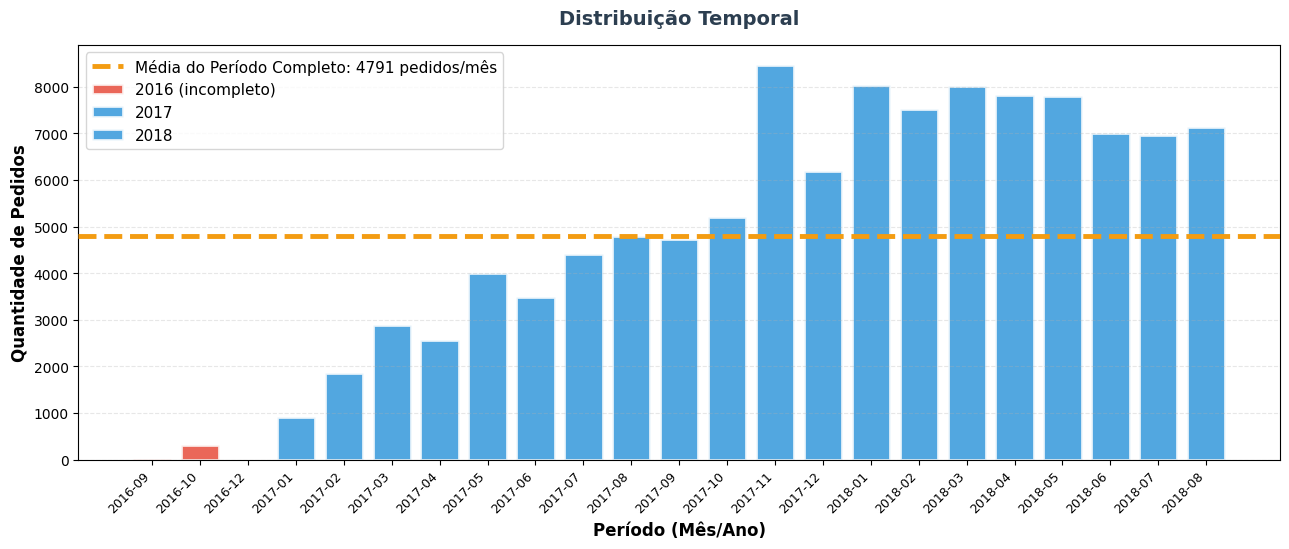

In [45]:
#@title 🔵 Limpeza Inicial

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ Remove apenas dados fora do escopo: status não-entregue,                     ║
# ║ ano incompleto e registros sem datas essenciais.                             ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ============================================================================
# CHECKPOINT INDEPENDENTE PARA ESTE BLOCO
# ============================================================================
if 'base_checkpoint_31' not in globals():
    # Primeira execução: salvar entrada deste bloco
    base_checkpoint_31 = base.copy()
    registros_inicial = len(base)
    print(f"🔵 Checkpoint 3.1 criado: {registros_inicial:,} registros")
else:
    # Reexecução: restaurar entrada original deste bloco
    base = base_checkpoint_31.copy()
    registros_inicial = len(base)
    print(f"🔄 Checkpoint 3.1 restaurado: {registros_inicial:,} registros")

# ============================================================================
# FILTRO 1: APENAS PEDIDOS ENTREGUES
# ============================================================================
base_limpa = base[base['status_pedido'] == 'delivered'].copy()
removidos_status = registros_inicial - len(base_limpa)

display(HTML(f"""
<div style='
    background: linear-gradient(135deg, #2E86C1 0%, #1F618D 100%);
    color: white;
    padding: 20px;
    border-radius: 10px;
    margin: 20px 0;
    box-shadow: 0 4px 12px rgba(0,0,0,0.15);
'>
    <div style='text-align:center; margin-bottom: 15px;'>
        <strong style='font-size: 18px;'>✅ Filtro: Manter Apenas status entregues</strong>
    </div>
    <div style='background:rgba(255,255,255,0.15); padding:15px; border-radius:8px;'>
        <strong>📌 Justificativa:</strong><br>
        • Objetivo: prever <strong>tempo de entrega</strong><br>
        • Pedidos cancelados/processando não possuem tempo de entrega válido<br>
        • Removidos: <strong>{removidos_status:,}</strong> registros ({removidos_status/registros_inicial*100:.1f}%)<br>
        • Restam: <strong>{len(base_limpa):,}</strong> registros
    </div>
</div>
"""))

# ============================================================================
# ANÁLISE TEMPORAL
# ============================================================================
base_limpa['ano_mes'] = base_limpa['data_compra_pedido'].dt.to_period('M')
pedidos_por_mes = base_limpa.groupby('ano_mes').size().reset_index(name='quantidade')
pedidos_por_mes['ano_mes_str'] = pedidos_por_mes['ano_mes'].astype(str)
pedidos_por_mes['ano'] = pedidos_por_mes['ano_mes_str'].str[:4]

# Separar por ano
dados_2016 = pedidos_por_mes[pedidos_por_mes['ano'] == '2016'].copy()
dados_2017 = pedidos_por_mes[pedidos_por_mes['ano'] == '2017'].copy()
dados_2018 = pedidos_por_mes[pedidos_por_mes['ano'] == '2018'].copy()

# Estatísticas
qtd_2016 = dados_2016['quantidade'].sum()
meses_2016 = len(dados_2016)
media_2016 = dados_2016['quantidade'].mean() if len(dados_2016) > 0 else 0
media_geral = pedidos_por_mes['quantidade'].mean()

# Gráfico temporal
fig, ax = plt.subplots(figsize=(13, 5.6))

if len(dados_2016) > 0:
    ax.bar(dados_2016['ano_mes_str'], dados_2016['quantidade'],
           color='#E74C3C', alpha=0.85, label='2016 (incompleto)',
           edgecolor='white', linewidth=2)

ax.bar(dados_2017['ano_mes_str'], dados_2017['quantidade'],
       color='#3498DB', alpha=0.85, label='2017',
       edgecolor='white', linewidth=2)

ax.bar(dados_2018['ano_mes_str'], dados_2018['quantidade'],
       color='#3498DB', alpha=0.85, label='2018',
       edgecolor='white', linewidth=2)

ax.axhline(media_geral, color='#F39C12', linestyle='--', linewidth=3.5,
           label=f'Média do Período Completo: {media_geral:.0f} pedidos/mês', zorder=10)

ax.set_xlabel('Período (Mês/Ano)', fontsize=12, fontweight='bold')
ax.set_ylabel('Quantidade de Pedidos', fontsize=12, fontweight='bold')
ax.set_title('Distribuição Temporal',
             fontsize=14, fontweight='bold', color='#2C3E50', pad=15)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

# ============================================================================
# FILTRO 2: REMOVER 2016
# ============================================================================
antes_2016 = len(base_limpa)
base_limpa = base_limpa[base_limpa['data_compra_pedido'].dt.year > 2016].copy()
removidos_2016 = antes_2016 - len(base_limpa)

display(HTML(f"""
<div style='
    background: linear-gradient(135deg, #2874A6 0%, #1A5276 100%);
    color: white;
    padding: 20px;
    border-radius: 10px;
    margin: 20px 0;
    box-shadow: 0 4px 12px rgba(0,0,0,0.15);
'>
    <div style='text-align:center; margin-bottom: 15px;'>
        <strong style='font-size: 18px;'>✅ Filtro: remover 2016</strong>
    </div>
    <div style='background:rgba(255,255,255,0.15); padding:15px; border-radius:8px;'>
        <strong>📌 Justificativa:</strong><br>
        • Dataset inclui apenas <strong>{meses_2016} meses</strong> de 2016 ({qtd_2016:,} pedidos)<br>
        • Média 2016: {media_2016:.0f} vs Média Geral: {media_geral:.0f} pedidos/mês<br>
        • Removidos: <strong>{removidos_2016:,}</strong> registros ({removidos_2016/antes_2016*100:.1f}%)<br>
        • Restam: <strong>{len(base_limpa):,}</strong> registros
    </div>
</div>
"""))

# ============================================================================
# FILTRO 3: VALIDAÇÃO DE DATAS ESSENCIAIS
# ============================================================================
antes_datas = len(base_limpa)
base_limpa = base_limpa[
    base_limpa['data_compra_pedido'].notna() &
    base_limpa['data_entrega_cliente'].notna()
].copy()
removidos_datas = antes_datas - len(base_limpa)

display(HTML(f"""
<div style='
    background: linear-gradient(135deg, #21618C 0%, #154360 100%);
    color: white;
    padding: 20px;
    border-radius: 10px;
    margin: 20px 0;
    box-shadow: 0 4px 12px rgba(0,0,0,0.15);
'>
    <div style='text-align:center; margin-bottom: 15px;'>
        <strong style='font-size: 18px;'>✅ Filtro: apenas datas válidas </strong>
    </div>
    <div style='background:rgba(255,255,255,0.15); padding:15px; border-radius:8px;'>
        <strong>📌 Critério:</strong><br>
        • Pedidos precisam ter data de compra e entrega<br>
        • Removidos: <strong>{removidos_datas:,}</strong> registros ({removidos_datas/antes_datas*100:.2f}%)<br>
        • Restam: <strong>{len(base_limpa):,}</strong> registros
    </div>
</div>
"""))

# ============================================================================
# RESUMO FINAL
# ============================================================================
total_removido = registros_inicial - len(base_limpa)
perc_removido = total_removido / registros_inicial * 100

display(HTML(f"""
<div style='
    background: linear-gradient(135deg, #1F618D 0%, #154360 100%);
    color: white;
    padding: 30px;
    border-radius: 12px;
    margin: 30px 0;
    box-shadow: 0 6px 20px rgba(0,0,0,0.25);
'>
    <h2 style='margin: 0 0 25px 0; text-align:center; font-size: 26px;'>
       LIMPEZA INICIAL
    </h2>

    <div style='display: grid; grid-template-columns: repeat(3, 1fr); gap: 20px; margin-bottom: 20px;'>
        <div style='background:rgba(255,255,255,0.2); padding:20px; border-radius:10px; text-align:center;'>
            <div style='font-size: 14px; opacity: 0.9; margin-bottom:8px;'>📊 Registros Iniciais</div>
            <div style='font-size: 36px; font-weight: bold;'>{registros_inicial:,}</div>
        </div>

        <div style='background:rgba(255,255,255,0.2); padding:20px; border-radius:10px; text-align:center;'>
            <div style='font-size: 14px; opacity: 0.9; margin-bottom:8px;'>🗑️ Removidos</div>
            <div style='font-size: 36px; font-weight: bold;'>{total_removido:,}</div>
            <div style='font-size: 13px; opacity: 0.9;'>({perc_removido:.1f}%)</div>
        </div>

        <div style='background:rgba(255,255,255,0.2); padding:20px; border-radius:10px; text-align:center;'>
            <div style='font-size: 14px; opacity: 0.9; margin-bottom:8px;'>✅ Restantes</div>
            <div style='font-size: 36px; font-weight: bold;'>{len(base_limpa):,}</div>
        </div>
    </div>
</div>
"""))

base = base_limpa.copy()

In [46]:
#@title 🔵 Preparação Inicial: novas variáveis

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ Cria features a partir dos dados limpos do Bloco 3.1                         ║
# ║ - dias_entrega (feature principal)                                           ║
# ║ - Features temporais (mês, dia da semana, trimestre)                         ║
# ║ - Features geográficas (mesma UF, etc)                                       ║
# ║ NÃO remove nada - apenas enriquece os dados                                  ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ============================================================================
# CHECKPOINT INDEPENDENTE
# ============================================================================
if 'base_checkpoint_32' not in globals():
    base_checkpoint_32 = base.copy()
    registros_inicial = len(base)
    print(f"🔵 Checkpoint 3.2 criado: {registros_inicial:,} registros")
else:
    base = base_checkpoint_32.copy()
    registros_inicial = len(base)


# ============================================================================
# 1. FEATURE PRINCIPAL: dias_entrega
# ============================================================================
if 'dias_entrega' not in base.columns:
    base['dias_entrega'] = (
        base['data_entrega_cliente'] - base['data_compra_pedido']
    ).dt.total_seconds() / 86400


# Estatísticas básicas
media_dias = base['dias_entrega'].mean()
mediana_dias = base['dias_entrega'].median()
min_dias = base['dias_entrega'].min()
max_dias = base['dias_entrega'].max()

display(HTML(f"""
<div style='
    background: linear-gradient(135deg, #2E86C1 0%, #1F618D 100%);
    color: white;
    padding: 20px;
    border-radius: 10px;
    margin: 20px 0;
    box-shadow: 0 4px 12px rgba(0,0,0,0.15);
'>
    <div style='text-align:center; margin-bottom: 15px;'>
        <strong style='font-size: 18px;'>📦 Feature Principal Criada: dias_entrega</strong>
    </div>
    <div style='background:rgba(255,255,255,0.15); padding:15px; border-radius:8px;'>
        <strong>📊 Estatísticas Iniciais:</strong><br>
        • Média: <strong>{media_dias:.2f}</strong> dias<br>
        • Mediana: <strong>{mediana_dias:.2f}</strong> dias<br>
        • Mínimo: <strong>{min_dias:.2f}</strong> dias<br>
        • Máximo: <strong>{max_dias:.2f}</strong> dias<br>
        <br>
        <em>Nota: Valores extremos serão tratados no Bloco 3.4</em>
    </div>
</div>
"""))

# ============================================================================
# 2. FEATURES TEMPORAIS
# ============================================================================
features_temporais = []

# Mês da compra
if 'mes_compra' not in base.columns:
    base['mes_compra'] = base['data_compra_pedido'].dt.month
    features_temporais.append('mes_compra')

# Dia da semana (0=segunda, 6=domingo)
if 'dia_semana_compra' not in base.columns:
    base['dia_semana_compra'] = base['data_compra_pedido'].dt.dayofweek
    features_temporais.append('dia_semana_compra')

# Trimestre
if 'trimestre_compra' not in base.columns:
    base['trimestre_compra'] = base['data_compra_pedido'].dt.quarter
    features_temporais.append('trimestre_compra')

# Ano (útil para análises temporais)
if 'ano_compra' not in base.columns:
    base['ano_compra'] = base['data_compra_pedido'].dt.year
    features_temporais.append('ano_compra')

# É fim de semana?
if 'eh_fds' not in base.columns:
    base['eh_fds'] = (base['dia_semana_compra'] >= 5).astype(int)
    features_temporais.append('eh_fds')

print(f"✅ Features temporais criadas: {', '.join(features_temporais)}")


# ============================================================================
# 3. FEATURES GEOGRÁFICAS
# ============================================================================
features_geograficas = []

# Mesma UF (cliente e vendedor no mesmo estado)
if 'estado_cliente' in base.columns and 'estado_vendedor' in base.columns:
    if 'mesma_uf' not in base.columns:
        base['mesma_uf'] = (
            base['estado_cliente'] == base['estado_vendedor']
        ).astype(int)
        features_geograficas.append('mesma_uf')

        # Estatística
        pct_mesma_uf = (base['mesma_uf'].sum() / len(base)) * 100
        print(f"✅ Feature 'mesma_uf' criada: {pct_mesma_uf:.1f}% dos pedidos são intra-estaduais")

    # Mesma Região (cliente e vendedor na mesma região geográfica)
    if 'mesma_regiao' not in base.columns:
        regioes = {
            'SP': 'Sudeste', 'RJ': 'Sudeste', 'MG': 'Sudeste', 'ES': 'Sudeste',
            'PR': 'Sul', 'SC': 'Sul', 'RS': 'Sul',
            'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'DF': 'Centro-Oeste',
            'BA': 'Nordeste', 'CE': 'Nordeste', 'PE': 'Nordeste', 'MA': 'Nordeste',
            'RN': 'Nordeste', 'PB': 'Nordeste', 'SE': 'Nordeste', 'AL': 'Nordeste', 'PI': 'Nordeste',
            'AM': 'Norte', 'PA': 'Norte', 'AC': 'Norte', 'RO': 'Norte',
            'RR': 'Norte', 'AP': 'Norte', 'TO': 'Norte'
        }

        base['regiao_cliente'] = base['estado_cliente'].map(regioes)
        base['regiao_vendedor'] = base['estado_vendedor'].map(regioes)
        base['mesma_regiao'] = (
            base['regiao_cliente'] == base['regiao_vendedor']
        ).astype(int)
        features_geograficas.append('mesma_regiao')

        # Estatística
        pct_mesma_regiao = (base['mesma_regiao'].sum() / len(base)) * 100
        print(f"✅ Feature 'mesma_regiao' criada: {pct_mesma_regiao:.1f}% dos pedidos são intra-regionais")

if len(features_geograficas) > 0:
    print(f"\n✅ Features geográficas criadas: {', '.join(features_geograficas)}")
else:
    print("\nℹ️ Colunas geográficas não encontradas ou já existem")

# ============================================================================
# 4. FEATURES DE VALOR (se existirem)
# ============================================================================
features_valor = []

# Preço médio por item (se tiver quantidade)
if 'valor_produto' in base.columns or 'preco' in base.columns:
    col_valor = 'valor_produto' if 'valor_produto' in base.columns else 'preco'

    # Categorizar faixa de valor
    if 'faixa_valor' not in base.columns:
        base['faixa_valor'] = pd.cut(
            base[col_valor],
            bins=[0, 50, 100, 200, float('inf')],
            labels=['Baixo (<50)', 'Médio (50-100)', 'Alto (100-200)', 'Premium (>200)']
        )
        features_valor.append('faixa_valor')
        print(f"✅ Feature 'faixa_valor' criada")

if len(features_valor) > 0:
    print(f"✅ Features de valor criadas: {', '.join(features_valor)}")

# ============================================================================
# 5. RESUMO FINAL DAS FEATURES CRIADAS
# ============================================================================
todas_features = ['dias_entrega'] + features_temporais + features_geograficas + features_valor
n_features_criadas = len(todas_features)

display(HTML(f"""
<div style='
    background: linear-gradient(135deg, #1F618D 0%, #154360 100%);
    color: white;
    padding: 30px;
    border-radius: 12px;
    margin: 30px 0;
    box-shadow: 0 6px 20px rgba(0,0,0,0.25);
'>
    <h2 style='margin: 0 0 25px 0; text-align:center; font-size: 26px;'>
        📊 PREPARAÇÃO CONCLUÍDA
    </h2>

    <div style='display: grid; grid-template-columns: repeat(3, 1fr); gap: 20px; margin-bottom: 20px;'>
        <div style='background:rgba(255,255,255,0.2); padding:20px; border-radius:10px; text-align:center;'>
            <div style='font-size: 14px; opacity: 0.9; margin-bottom:8px;'>📋 Registros</div>
            <div style='font-size: 36px; font-weight: bold;'>{len(base):,}</div>
        </div>

        <div style='background:rgba(255,255,255,0.2); padding:20px; border-radius:10px; text-align:center;'>
            <div style='font-size: 14px; opacity: 0.9; margin-bottom:8px;'>✨ Features Criadas</div>
            <div style='font-size: 36px; font-weight: bold;'>{n_features_criadas}</div>
        </div>

        <div style='background:rgba(255,255,255,0.2); padding:20px; border-radius:10px; text-align:center;'>
            <div style='font-size: 14px; opacity: 0.9; margin-bottom:8px;'>📊 Colunas Totais</div>
            <div style='font-size: 36px; font-weight: bold;'>{len(base.columns)}</div>
        </div>
    </div>

    <div style='background:rgba(255,255,255,0.15); padding:20px; border-radius:10px;'>
        <strong style='font-size: 16px;'>✅ Features Criadas:</strong><br><br>
        <strong>Principal:</strong> dias_entrega<br>
        <strong>Temporais:</strong> {', '.join(features_temporais) if features_temporais else 'N/A'}<br>
        <strong>Geográficas:</strong> {', '.join(features_geograficas) if features_geograficas else 'N/A'}<br>
        <strong>Valor:</strong> {', '.join(features_valor) if features_valor else 'N/A'}
    </div>
</div>
"""))

✅ Features temporais criadas: mes_compra, dia_semana_compra, trimestre_compra, ano_compra, eh_fds
✅ Feature 'mesma_uf' criada: 36.2% dos pedidos são intra-estaduais
✅ Feature 'mesma_regiao' criada: 62.4% dos pedidos são intra-regionais

✅ Features geográficas criadas: mesma_uf, mesma_regiao
✅ Feature 'faixa_valor' criada
✅ Features de valor criadas: faixa_valor


,Variável,Q1 (25%),Q3 (75%),IQR,Limite Superior,Outliers Detectados,Percentual
1,dias_entrega,6.7,15.5,8.8,28.7 dias,"5,696",5.2%
2,peso_g,300g,1800g,1500g,4050g,"15,389",14.0%


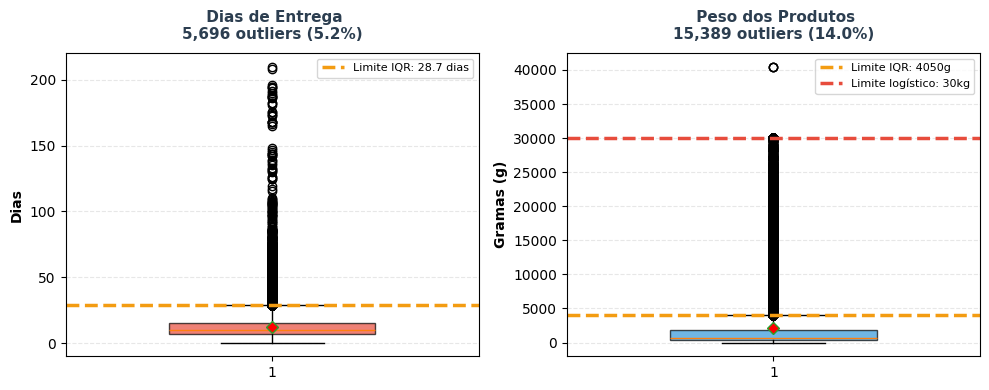

In [47]:
#@title 🔵 Identificação de Inconsistências e Outliers

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ Identifica problemas nos dados SEM remover nada ainda.                      ║
# ║ Foca nas variáveis CRÍTICAS para previsão de tempo de entrega.              ║
# ╚══════════════════════════════════════════════════════════════════════════════╝


# ═════════════════════════════════════════════════════════════════
# 0. CRIAR dias_entrega SE NÃO EXISTIR (CORREÇÃO!)
# ═════════════════════════════════════════════════════════════════

if 'dias_entrega' not in base.columns:
    print("📝 Criando coluna dias_entrega...\n")
    base['dias_entrega'] = (
        base['data_entrega_cliente'] - base['data_compra_pedido']
    ).dt.days

    # Remover valores inválidos
    antes_criacao = len(base)
    base = base[(base['dias_entrega'].notna()) & (base['dias_entrega'] >= 0)].copy()
    removidos_criacao = antes_criacao - len(base)

    if removidos_criacao > 0:
        print(f"   ⚠️ Removidos {removidos_criacao:,} registros com dias_entrega inválidos")
    print(f"   ✅ dias_entrega criado: média de {base['dias_entrega'].mean():.1f} dias\n")

# ═════════════════════════════════════════════════════════════════
# 1. IDENTIFICAR INCONSISTÊNCIAS LÓGICAS
# ═════════════════════════════════════════════════════════════════

# Marcar inconsistências
base['inconsistencias'] = ''

def marcar(df, mask, texto):
    """Adiciona descrição de inconsistência aos registros problemáticos"""
    df.loc[mask, 'inconsistencias'] = df.loc[mask, 'inconsistencias'].apply(
        lambda x: texto if x == '' else x + "; " + texto
    )

# Inconsistências temporais (as mais graves)
marcar(base, base['data_aprovacao_pedido'] < base['data_compra_pedido'],
       'Aprovação antes da compra')
marcar(base, (base['data_entrega_cliente'].notna()) &
              (base['data_entrega_cliente'] < base['data_aprovacao_pedido']),
       'Entrega antes da aprovação')
marcar(base, (base['data_entrega_cliente'].notna()) &
              (base['data_entrega_transportadora'].notna()) &
              (base['data_entrega_cliente'] < base['data_entrega_transportadora']),
       'Entrega antes do envio')

# Inconsistências numéricas
marcar(base, (base['preco'].notna()) & (base['preco'] <= 0), 'Preço inválido')
marcar(base, (base['valor_frete'].notna()) & (base['valor_frete'] < 0), 'Frete negativo')

# Verificar se peso_g existe antes de usar
if 'peso_g' in base.columns:
    marcar(base, (base['peso_g'].notna()) & (base['peso_g'] <= 0), 'Peso inválido')

# Criar flag binária
base['tem_inconsistencia'] = (base['inconsistencias'] != '').astype(int)

total_incons = base['tem_inconsistencia'].sum()
perc_incons = (total_incons / len(base)) * 100

display(HTML(f"""
<div style='
    background: linear-gradient(135deg, #2E86C1 0%, #1F618D 100%);
    color: white;
    padding: 20px;
    border-radius: 10px;
    margin: 20px 0;
    box-shadow: 0 4px 12px rgba(0,0,0,0.15);
'>
    <div style='text-align:center; margin-bottom: 15px;'>
        <strong style='font-size: 18px;'>⚠️ Inconsistências Verificadas</strong>
    </div>
    <div style='background:rgba(255,255,255,0.15); padding:15px; border-radius:8px;'>
        <strong>📊 Total:</strong> <strong>{total_incons:,}</strong> registros ({perc_incons:.2f}%)<br>
    </div>
</div>
"""))

# ═════════════════════════════════════════════════════════════════
# 2. ANALISAR OUTLIERS (APENAS VARIÁVEIS CRÍTICAS)
# ═════════════════════════════════════════════════════════════════

def analisar_outliers(serie, nome_var):
    """Calcula estatísticas de outliers usando método IQR"""
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR

    outliers_count = ((serie < limite_inf) | (serie > limite_sup)).sum()
    outliers_perc = (outliers_count / len(serie)) * 100

    return outliers_count, limite_sup, outliers_perc, Q1, Q3, IQR

# Analisar dias_entrega
out_dias, lim_dias, perc_dias, Q1_dias, Q3_dias, IQR_dias = analisar_outliers(
    base['dias_entrega'].dropna(),
    'dias_entrega'
)

# Analisar peso_g (SE EXISTIR)
if 'peso_g' in base.columns:
    out_peso, lim_peso, perc_peso, Q1_peso, Q3_peso, IQR_peso = analisar_outliers(
        base['peso_g'].dropna(),
        'peso_g'
    )
else:
    out_peso, lim_peso, perc_peso = 0, 0, 0
    Q1_peso, Q3_peso, IQR_peso = 0, 0, 0

# ═════════════════════════════════════════════════════════════════
# 3. TABELA DETALHADA DE OUTLIERS
# ═════════════════════════════════════════════════════════════════

if 'peso_g' in base.columns:
    df_outliers = pd.DataFrame({
        'Variável': ['dias_entrega', 'peso_g'],
        'Q1 (25%)': [f'{Q1_dias:.1f}', f'{Q1_peso:.0f}g'],
        'Q3 (75%)': [f'{Q3_dias:.1f}', f'{Q3_peso:.0f}g'],
        'IQR': [f'{IQR_dias:.1f}', f'{IQR_peso:.0f}g'],
        'Limite Superior': [f'{lim_dias:.1f} dias', f'{lim_peso:.0f}g'],
        'Outliers Detectados': [f'{out_dias:,}', f'{out_peso:,}'],
        'Percentual': [f'{perc_dias:.1f}%', f'{perc_peso:.1f}%']
    })
else:
    df_outliers = pd.DataFrame({
        'Variável': ['dias_entrega'],
        'Q1 (25%)': [f'{Q1_dias:.1f}'],
        'Q3 (75%)': [f'{Q3_dias:.1f}'],
        'IQR': [f'{IQR_dias:.1f}'],
        'Limite Superior': [f'{lim_dias:.1f} dias'],
        'Outliers Detectados': [f'{out_dias:,}'],
        'Percentual': [f'{perc_dias:.1f}%']
    })

df_outliers.index = range(1, len(df_outliers) + 1)

display(estilo_tabela(df_outliers, "📊 Análise dos Outliers (Método IQR)"))

print("\n" * 3)  # Espaçamento entre tabela e gráfico

# ═════════════════════════════════════════════════════════════════
# 4. VISUALIZAÇÃO: BOXPLOTS
# ═════════════════════════════════════════════════════════════════

# Determinar quantos gráficos criar
num_plots = 2 if 'peso_g' in base.columns else 1
fig, axes = plt.subplots(1, num_plots, figsize=(10 if num_plots == 2 else 5, 4))

if num_plots == 1:
    axes = [axes]  # Transformar em lista para manter consistência

# Boxplot 1: Dias de Entrega
bp1 = axes[0].boxplot([base['dias_entrega'].dropna()], vert=True, patch_artist=True,
                       widths=0.5, showmeans=True,
                       meanprops=dict(marker='D', markerfacecolor='red', markersize=6))
bp1['boxes'][0].set_facecolor('#E74C3C')
bp1['boxes'][0].set_alpha(0.7)
axes[0].axhline(lim_dias, color='#F39C12', linestyle='--', linewidth=2.5,
                label=f'Limite IQR: {lim_dias:.1f} dias')
axes[0].set_title(f' Dias de Entrega\n{out_dias:,} outliers ({perc_dias:.1f}%)',
                  fontsize=11, fontweight='bold', color='#2C3E50', pad=10)
axes[0].set_ylabel('Dias', fontsize=10, fontweight='bold')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# Boxplot 2: Peso (SE EXISTIR)
if 'peso_g' in base.columns:
    bp2 = axes[1].boxplot([base['peso_g'].dropna()], vert=True, patch_artist=True,
                           widths=0.5, showmeans=True,
                           meanprops=dict(marker='D', markerfacecolor='red', markersize=6))
    bp2['boxes'][0].set_facecolor('#3498DB')
    bp2['boxes'][0].set_alpha(0.7)
    axes[1].axhline(lim_peso, color='#F39C12', linestyle='--', linewidth=2.5,
                    label=f'Limite IQR: {lim_peso:.0f}g')
    axes[1].axhline(30000, color='#E74C3C', linestyle='--', linewidth=2.5,
                    label='Limite logístico: 30kg')
    axes[1].set_title(f' Peso dos Produtos\n{out_peso:,} outliers ({perc_peso:.1f}%)',
                      fontsize=11, fontweight='bold', color='#2C3E50', pad=10)
    axes[1].set_ylabel('Gramas (g)', fontsize=10, fontweight='bold')
    axes[1].legend(fontsize=8, loc='upper right')
    axes[1].grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

# ═════════════════════════════════════════════════════════════════
# 5. DASHBOARD DE RESUMO
# ═════════════════════════════════════════════════════════════════

display(HTML(f"""
<div style='
    background: linear-gradient(135deg, #1F618D 0%, #154360 100%);
    color: white;
    padding: 30px;
    border-radius: 12px;
    margin: 30px 0;
    box-shadow: 0 6px 20px rgba(0,0,0,0.3);
'>
    <h3 style='margin: 0 0 25px 0; text-align:center; font-size: 22px;'>
        🔍 RESUMO DOS PROBLEMAS IDENTIFICADOS
    </h3>

    <div style='display: grid; grid-template-columns: repeat(3, 1fr); gap: 20px; margin-bottom: 20px;'>
        <div style='background:rgba(255,255,255,0.2); padding:20px; border-radius:8px; text-align:center;'>
            <div style='font-size:14px; opacity:0.9; margin-bottom:8px;'>⚠️ Inconsistências</div>
            <div style='font-size:40px; font-weight:bold;'>{total_incons:,}</div>
            <div style='font-size:12px; opacity:0.9; margin-top:5px;'>({perc_incons:.2f}% do total)</div>
        </div>

        <div style='background:rgba(255,255,255,0.2); padding:20px; border-radius:8px; text-align:center;'>
            <div style='font-size:14px; opacity:0.9; margin-bottom:8px;'>📊 Outliers (Dias)</div>
            <div style='font-size:40px; font-weight:bold;'>{out_dias:,}</div>
            <div style='font-size:12px; opacity:0.9; margin-top:5px;'>({perc_dias:.1f}% acima de {lim_dias:.0f}d)</div>
        </div>

        <div style='background:rgba(255,255,255,0.2); padding:20px; border-radius:8px; text-align:center;'>
            <div style='font-size:14px; opacity:0.9; margin-bottom:8px;'>⚖️ Outliers (Peso)</div>
            <div style='font-size:40px; font-weight:bold;'>{out_peso:,}</div>
            <div style='font-size:12px; opacity:0.9; margin-top:5px;'>({'N/A' if out_peso == 0 else f'{perc_peso:.1f}% acima de {lim_peso:.0f}g'})</div>
        </div>
    </div>

    <div style='background:rgba(255,255,255,0.15); padding:20px; border-radius:8px; margin-bottom:15px;'>
        <strong style='font-size:16px;'>🎯 Interpretação dos Resultados:</strong><br><br>

        <strong>Inconsistências ({total_incons:,} registros):</strong><br>
        • Representam {perc_incons:.2f}% da base - um volume {'BAIXO ✅' if perc_incons < 1 else 'MODERADO ⚠️' if perc_incons < 5 else 'ALTO 🚨'}<br>
        • Podem ou não impactar o tempo de entrega (será testado no Bloco 3.5)<br><br>

        <strong>Outliers em dias_entrega ({out_dias:,} registros):</strong><br>
        • Entregas com >{lim_dias:.0f} dias são consideradas atípicas<br>
        • Podem ser pedidos extraviados, devolvidos ou com problemas logísticos<br>
        • {'ALTO impacto' if perc_dias > 5 else 'MODERADO impacto' if perc_dias > 2 else 'BAIXO impacto'} no modelo ({perc_dias:.1f}% da base)<br><br>

        <strong>Outliers em peso ({'N/A' if out_peso == 0 else f'{out_peso:,} registros'}):</strong><br>
        • {'Coluna peso_g não disponível' if out_peso == 0 else f'Produtos com >{lim_peso:.0f}g podem ter logística diferenciada'}<br>
        • {'Análise será feita após agregação' if out_peso == 0 else 'Limite prático: 30kg (máximo para entrega residencial padrão)'}<br>
        • {'N/A' if out_peso == 0 else f"{'ALTO volume' if perc_peso > 5 else 'MODERADO volume' if perc_peso > 2 else 'BAIXO volume'} de outliers ({perc_peso:.1f}%)"}
    </div>
</div>
"""))

🔄 Checkpoint 3.4 restaurado: 109,872 registros

🔧 Removendo outliers simultaneamente...



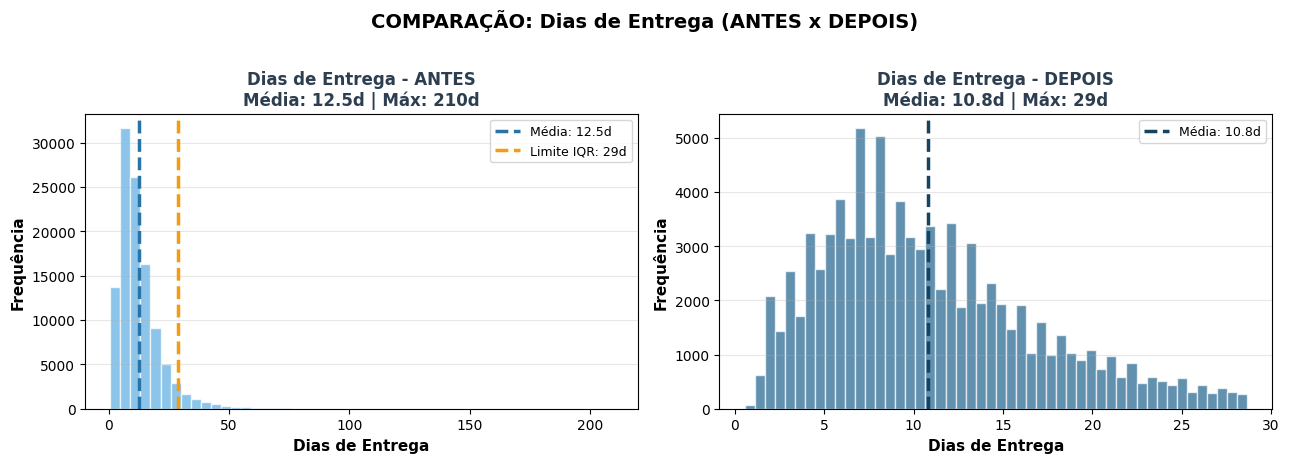

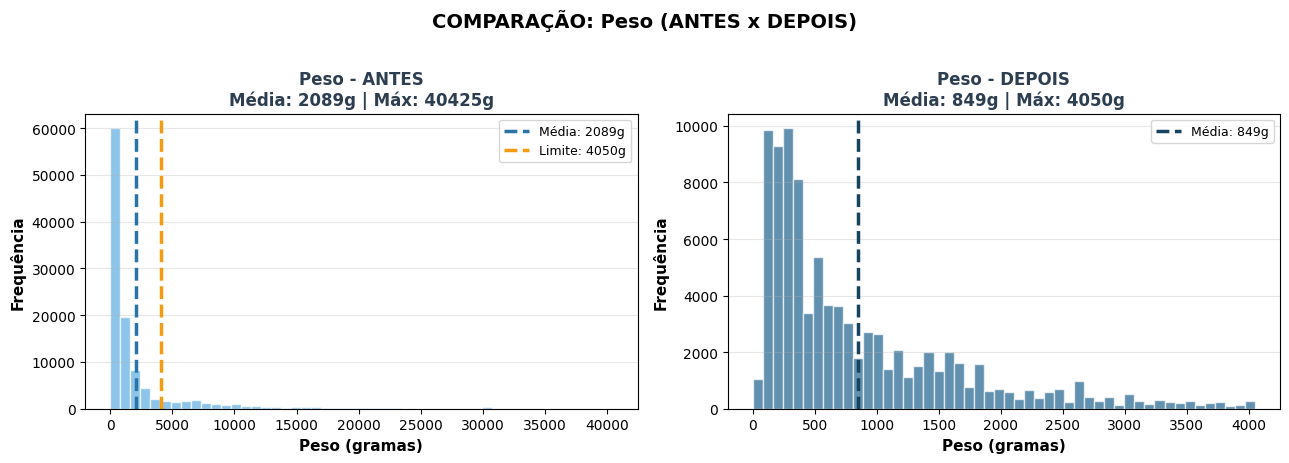

,Métrica,Antes,Depois,Mudança
1,Registros Totais,"109,872","89,924","-19,948"
2,Dias - Média,12.5,10.8,-1.7
3,Dias - Máximo,210,29,-181
4,Peso - Média (g),2089,849,-1240
5,Peso - Máximo (g),40425,4050,-36375



✅ Bloco 3.4 concluído: 89,924 registros
   • Outliers de dias removidos: 5,696
   • Outliers de peso removidos: 15,389
   • Total removido: 19,948 (18.2%)


In [48]:
#@title 🔵 Tratamento de Outliers

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ Remove outliers de dias_entrega E peso_g DE UMA VEZ (não sequencial)         ║
# ║ Isso garante que as contagens batam com o Bloco 3.3                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ═════════════════════════════════════════════════════════════════
# CHECKPOINT CORRETO
# ═════════════════════════════════════════════════════════════════

if 'base_checkpoint_34' not in globals():
    base_checkpoint_34 = base.copy()
    registros_inicial = len(base)
    print(f"🔵 Checkpoint 3.4 criado: {registros_inicial:,} registros")
else:
    base = base_checkpoint_34.copy()
    registros_inicial = len(base)
    print(f"🔄 Checkpoint 3.4 restaurado: {registros_inicial:,} registros")

# ═════════════════════════════════════════════════════════════════
# GARANTIR QUE dias_entrega EXISTE
# ═════════════════════════════════════════════════════════════════

if 'dias_entrega' not in base.columns:
    print("\n⚠️ Criando coluna dias_entrega...\n")
    base['dias_entrega'] = (
        base['data_entrega_cliente'] - base['data_compra_pedido']
    ).dt.total_seconds() / 86400

    antes_criacao = len(base)
    base = base[(base['dias_entrega'].notna()) & (base['dias_entrega'] >= 0)].copy()
    removidos_criacao = antes_criacao - len(base)

    if removidos_criacao > 0:
        print(f"   ⚠️ Removidos {removidos_criacao:,} registros com dias_entrega inválidos")
    print(f"   ✅ dias_entrega criado: média de {base['dias_entrega'].mean():.1f} dias\n")

    registros_inicial = len(base)

# ═════════════════════════════════════════════════════════════════
# SALVAR DISTRIBUIÇÕES ANTES DO TRATAMENTO
# ═════════════════════════════════════════════════════════════════

dias_antes = base['dias_entrega'].copy()
peso_antes = base['peso_g'].copy()

media_dias_antes = dias_antes.mean()
max_dias_antes = dias_antes.max()
media_peso_antes = peso_antes.mean()
max_peso_antes = peso_antes.max()

# ═════════════════════════════════════════════════════════════════
# CALCULAR LIMITES (IQR)
# ═════════════════════════════════════════════════════════════════

# 1. DIAS_ENTREGA
Q1_dias = base['dias_entrega'].quantile(0.25)
Q3_dias = base['dias_entrega'].quantile(0.75)
IQR_dias = Q3_dias - Q1_dias
limite_inferior_dias = Q1_dias - 1.5 * IQR_dias
limite_superior_dias = Q3_dias + 1.5 * IQR_dias

# 2. PESO_G
Q1_peso = base['peso_g'].quantile(0.25)
Q3_peso = base['peso_g'].quantile(0.75)
IQR_peso = Q3_peso - Q1_peso
limite_superior_peso_iqr = Q3_peso + 1.5 * IQR_peso
limite_superior_peso = min(limite_superior_peso_iqr, 30000)

# ═════════════════════════════════════════════════════════════════
# CONTAR OUTLIERS ANTES DE REMOVER (para bater com Bloco 3.3)
# ═════════════════════════════════════════════════════════════════

outliers_dias_count = ((base['dias_entrega'] < limite_inferior_dias) |
                        (base['dias_entrega'] > limite_superior_dias)).sum()
outliers_peso_count = (base['peso_g'] > limite_superior_peso).sum()

perc_outliers_dias = (outliers_dias_count / len(base)) * 100
perc_outliers_peso = (outliers_peso_count / len(base)) * 100

# ═════════════════════════════════════════════════════════════════
# REMOVER OUTLIERS DE UMA VEZ (SIMULTANEAMENTE)
# ═════════════════════════════════════════════════════════════════

print("\n🔧 Removendo outliers simultaneamente...\n")

# Criar máscara única que combina AMBAS as condições
mascara_validos = (
    (base['dias_entrega'] >= limite_inferior_dias) &
    (base['dias_entrega'] <= limite_superior_dias) &
    (base['peso_g'] <= limite_superior_peso)
)

# Aplicar filtro UMA ÚNICA VEZ
base_limpa = base[mascara_validos].copy()

total_removidos = len(base) - len(base_limpa)
perc_total_removido = (total_removidos / len(base)) * 100

# ═════════════════════════════════════════════════════════════════
# ESTATÍSTICAS DEPOIS
# ═════════════════════════════════════════════════════════════════

dias_depois = base_limpa['dias_entrega']
peso_depois = base_limpa['peso_g']

media_dias_depois = dias_depois.mean()
max_dias_depois = dias_depois.max()
media_peso_depois = peso_depois.mean()
max_peso_depois = peso_depois.max()

# ═════════════════════════════════════════════════════════════════
# CARD DE RESUMO (AGORA COM VALORES CORRETOS!)
# ═════════════════════════════════════════════════════════════════

display(HTML(f"""
<div style='
    background: linear-gradient(135deg, #1F618D 0%, #154360 100%);
    color: white;
    padding: 30px;
    border-radius: 12px;
    margin: 30px 0;
    box-shadow: 0 6px 20px rgba(0,0,0,0.3);
'>
    <h3 style='margin: 0 0 25px 0; text-align:center; font-size: 22px;'>
        📊 RESUMO DO TRATAMENTO (Remoção Simultânea)
    </h3>

    <div style='display: grid; grid-template-columns: repeat(4, 1fr); gap: 15px; margin-bottom: 20px;'>
        <div style='background:rgba(255,255,255,0.2); padding:20px; border-radius:8px; text-align:center;'>
            <div style='font-size:13px; opacity:0.9; margin-bottom:8px;'>📊 Inicial</div>
            <div style='font-size:36px; font-weight:bold;'>{registros_inicial:,}</div>
        </div>

        <div style='background:rgba(255,255,255,0.2); padding:20px; border-radius:8px; text-align:center;'>
            <div style='font-size:13px; opacity:0.9; margin-bottom:8px;'>🗑️ Outliers Dias</div>
            <div style='font-size:36px; font-weight:bold;'>{outliers_dias_count:,}</div>
            <div style='font-size:11px; opacity:0.9; margin-top:5px;'>({perc_outliers_dias:.1f}%)</div>
        </div>

        <div style='background:rgba(255,255,255,0.2); padding:20px; border-radius:8px; text-align:center;'>
            <div style='font-size:13px; opacity:0.9; margin-bottom:8px;'>🗑️ Outliers Peso</div>
            <div style='font-size:36px; font-weight:bold;'>{outliers_peso_count:,}</div>
            <div style='font-size:11px; opacity:0.9; margin-top:5px;'>({perc_outliers_peso:.2f}%)</div>
        </div>

        <div style='background:rgba(255,255,255,0.2); padding:20px; border-radius:8px; text-align:center;'>
            <div style='font-size:13px; opacity:0.9; margin-bottom:8px;'>✅ Final</div>
            <div style='font-size:36px; font-weight:bold;'>{len(base_limpa):,}</div>
            <div style='font-size:11px; opacity:0.9; margin-top:5px;'>({100-perc_total_removido:.1f}%)</div>
        </div>
    </div>

    <div style='background:rgba(255,255,255,0.15); padding:18px; border-radius:8px;'>
        <strong style='font-size:16px;'>📋 Métodos Aplicados:</strong><br><br>
        • <strong>dias_entrega:</strong> IQR (1.5×) → Limite: {limite_superior_dias:.0f} dias<br>
        • <strong>peso_g:</strong> IQR + Domínio → Limite: {limite_superior_peso:.0f}g (30kg)<br>
        • <strong>Total removido:</strong> {total_removidos:,} registros ({perc_total_removido:.1f}%)
    </div>

    <div style='background:rgba(46,204,113,0.3); padding:15px; border-radius:8px; margin-top:15px; text-align:center;'>
        <strong style='font-size:14px;'>✅ Remoção simultânea garante contagens corretas</strong><br>
        <span style='font-size:12px;'>Os números agora batem com o Bloco 3.3 de identificação</span>
    </div>
</div>
"""))

# ═════════════════════════════════════════════════════════════════
# VISUALIZAÇÃO 1: DIAS_ENTREGA - ANTES x DEPOIS
# ═════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ANTES
axes[0].hist(dias_antes, bins=50, color='#5DADE2', alpha=0.7, edgecolor='white')
axes[0].axvline(media_dias_antes, color='#2874A6', linestyle='--', linewidth=2.5,
                  label=f'Média: {media_dias_antes:.1f}d')
axes[0].axvline(limite_superior_dias, color='#F39C12', linestyle='--', linewidth=2.5,
                  label=f'Limite IQR: {limite_superior_dias:.0f}d')
axes[0].set_xlabel('Dias de Entrega', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequência', fontsize=11, fontweight='bold')
axes[0].set_title(f'Dias de Entrega - ANTES\nMédia: {media_dias_antes:.1f}d | Máx: {max_dias_antes:.0f}d',
                    fontsize=12, fontweight='bold', color='#2C3E50')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# DEPOIS
axes[1].hist(dias_depois, bins=50, color='#1F618D', alpha=0.7, edgecolor='white')
axes[1].axvline(media_dias_depois, color='#154360', linestyle='--', linewidth=2.5,
                  label=f'Média: {media_dias_depois:.1f}d')
axes[1].set_xlabel('Dias de Entrega', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequência', fontsize=11, fontweight='bold')
axes[1].set_title(f'Dias de Entrega - DEPOIS\nMédia: {media_dias_depois:.1f}d | Máx: {max_dias_depois:.0f}d',
                    fontsize=12, fontweight='bold', color='#2C3E50')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('COMPARAÇÃO: Dias de Entrega (ANTES x DEPOIS)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" * 2)

# ═════════════════════════════════════════════════════════════════
# VISUALIZAÇÃO 2: PESO_G - ANTES x DEPOIS
# ═════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ANTES
axes[0].hist(peso_antes, bins=50, color='#5DADE2', alpha=0.7, edgecolor='white')
axes[0].axvline(media_peso_antes, color='#2874A6', linestyle='--', linewidth=2.5,
                  label=f'Média: {media_peso_antes:.0f}g')
axes[0].axvline(limite_superior_peso, color='#F39C12', linestyle='--', linewidth=2.5,
                  label=f'Limite: {limite_superior_peso:.0f}g')
axes[0].set_xlabel('Peso (gramas)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Frequência', fontsize=11, fontweight='bold')
axes[0].set_title(f'Peso - ANTES\nMédia: {media_peso_antes:.0f}g | Máx: {max_peso_antes:.0f}g',
                    fontsize=12, fontweight='bold', color='#2C3E50')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

# DEPOIS
axes[1].hist(peso_depois, bins=50, color='#1F618D', alpha=0.7, edgecolor='white')
axes[1].axvline(media_peso_depois, color='#154360', linestyle='--', linewidth=2.5,
                  label=f'Média: {media_peso_depois:.0f}g')
axes[1].set_xlabel('Peso (gramas)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequência', fontsize=11, fontweight='bold')
axes[1].set_title(f'Peso - DEPOIS\nMédia: {media_peso_depois:.0f}g | Máx: {max_peso_depois:.0f}g',
                    fontsize=12, fontweight='bold', color='#2C3E50')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('COMPARAÇÃO: Peso (ANTES x DEPOIS)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ═════════════════════════════════════════════════════════════════
# TABELA COMPARATIVA
# ═════════════════════════════════════════════════════════════════

df_comparacao = pd.DataFrame({
    'Métrica': [
        'Registros Totais',
        'Dias - Média',
        'Dias - Máximo',
        'Peso - Média (g)',
        'Peso - Máximo (g)'
    ],
    'Antes': [
        f'{registros_inicial:,}',
        f'{media_dias_antes:.1f}',
        f'{max_dias_antes:.0f}',
        f'{media_peso_antes:.0f}',
        f'{max_peso_antes:.0f}'
    ],
    'Depois': [
        f'{len(base_limpa):,}',
        f'{media_dias_depois:.1f}',
        f'{max_dias_depois:.0f}',
        f'{media_peso_depois:.0f}',
        f'{max_peso_depois:.0f}'
    ],
    'Mudança': [
        f'-{total_removidos:,}',
        f'{media_dias_depois - media_dias_antes:+.1f}',
        f'-{max_dias_antes - max_dias_depois:.0f}',
        f'{media_peso_depois - media_peso_antes:+.0f}',
        f'-{max_peso_antes - max_peso_depois:.0f}'
    ]
})
df_comparacao.index = range(1, len(df_comparacao) + 1)

display(estilo_tabela(df_comparacao, "📊 Comparação Detalhada: Antes vs Depois"))

# ═════════════════════════════════════════════════════════════════
# ATUALIZAR BASE PARA PRÓXIMO BLOCO
# ═════════════════════════════════════════════════════════════════

base = base_limpa.copy()

print(f"\n✅ Bloco 3.4 concluído: {len(base):,} registros")
print(f"   • Outliers de dias removidos: {outliers_dias_count:,}")
print(f"   • Outliers de peso removidos: {outliers_peso_count:,}")
print(f"   • Total removido: {total_removidos:,} ({perc_total_removido:.1f}%)")

In [49]:

#@title 🔵 Agregação (Itens → Pedidos)


# CHECKPOINT
if 'base_checkpoint_36' not in globals():
    base_checkpoint_36 = base.copy()
    base = base_checkpoint_36.copy()
    n_itens = len(base)
else:
    base = base_checkpoint_36.copy()
    n_itens = len(base)



# 🔍 Identificar coluna do pedido
coluna_pedido = None
for col in ['pedido_id', 'order_id', 'id_pedido', 'order_number']:
    if col in base.columns:
        coluna_pedido = col
        break

if coluna_pedido is None:
    print(" Nenhuma coluna de ID de pedido encontrada!")
    print("   Colunas disponíveis:", base.columns.tolist())
    base_pedidos = base.copy()

else:
    # Estatísticas pré-agregação
    n_pedidos_unicos = base[coluna_pedido].nunique()
    media_itens = n_itens / n_pedidos_unicos

    # =====================================================
    # AGREGAÇÕES (sem qtd_itens aqui para evitar erro!)
    # =====================================================
    agregacoes = {}

    # Datas e características
    for col in [
        'dias_entrega', 'data_compra_pedido', 'data_entrega_cliente',
        'mes_compra', 'dia_semana_compra', 'trimestre_compra',
        'estado_cliente', 'estado_vendedor', 'mesma_uf', 'mesma_regiao'
    ]:
        if col in base.columns:
            agregacoes[col] = 'first'

    # Valores
    if 'valor_produto' in base.columns:
        agregacoes['valor_produto'] = 'sum'
    elif 'preco' in base.columns:
        agregacoes['preco'] = 'sum'

    if 'frete' in base.columns:
        agregacoes['frete'] = 'first'
    elif 'freight_value' in base.columns:
        agregacoes['freight_value'] = 'first'

    # =====================================================
    # AGREGAR (sem qtd_itens)
    # =====================================================
    base_pedidos = base.groupby(coluna_pedido).agg(agregacoes).reset_index()

    # =====================================================
    # Adicionar qtd_itens de forma segura
    # =====================================================
    qtd_itens_series = base.groupby(coluna_pedido).size().rename("qtd_itens")

    base_pedidos = base_pedidos.merge(qtd_itens_series, on=coluna_pedido, how='left')


# VISUALIZAÇÃO
display(HTML(f"""
<div style='
    background: linear-gradient(135deg, #9B59B6 0%, #8E44AD 100%);
    color: white;
    padding: 30px;
    border-radius: 12px;
    margin: 30px 0;
    box-shadow: 0 6px 20px rgba(0,0,0,0.25);
'>
    <h2 style='margin: 0 0 25px 0; text-align:center; font-size: 26px;'>
        📦 AGREGAÇÃO CONCLUÍDA
    </h2>

    <div style='display: grid; grid-template-columns: repeat(3, 1fr); gap: 20px;'>
        <div style='background:rgba(255,255,255,0.2); padding:20px; border-radius:10px; text-align:center;'>
            <div style='font-size: 14px; opacity: 0.9; margin-bottom:8px;'>📊 Itens</div>
            <div style='font-size: 36px; font-weight: bold;'>{n_itens:,}</div>
        </div>

        <div style='background:rgba(255,255,255,0.2); padding:20px; border-radius:10px; text-align:center;'>
            <div style='font-size: 14px; opacity: 0.9; margin-bottom:8px;'>📋 Pedidos</div>
            <div style='font-size: 36px; font-weight: bold;'>{len(base_pedidos):,}</div>
        </div>

        <div style='background:rgba(255,255,255,0.2); padding:20px; border-radius:10px; text-align:center;'>
            <div style='font-size: 14px; opacity: 0.9; margin-bottom:8px;'>📦 Itens/Pedido</div>
            <div style='font-size: 36px; font-weight: bold;'>{(n_itens/len(base_pedidos)):.2f}</div>
        </div>
    </div>
</div>
"""))

# Atualizar base para o próximo bloco
base = base_pedidos.copy()

print(f"\n✅ Bloco 3.6 concluído: {len(base):,} PEDIDOS (agregados corretamente!)")



✅ Bloco 3.6 concluído: 78,551 PEDIDOS (agregados corretamente!)


 Analisando base atual: 78,551 registros
✅ Feature 'mesma_regiao' presente: 63.3% intra-regionais

 Analisando correlações entre 8 variáveis numéricas
   ✅ Feature 'mesma_regiao' incluída na análise


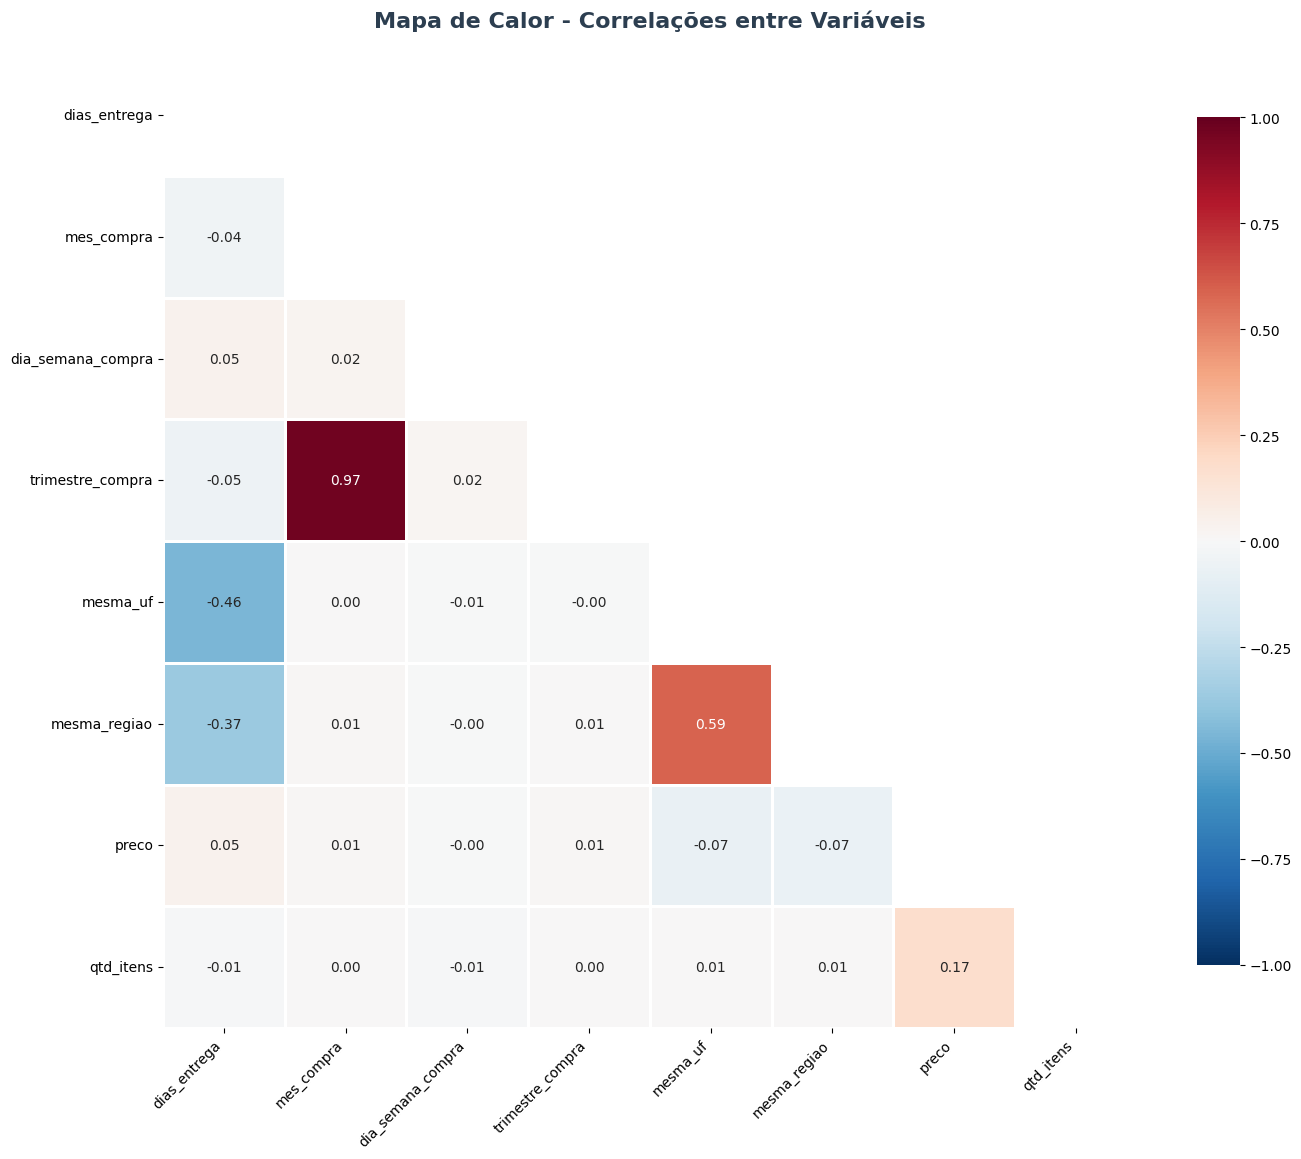


🎯 CORRELAÇÕES COM dias_entrega:
dias_entrega         1.000000
dia_semana_compra    0.046699
preco                0.045698
qtd_itens           -0.014407
mes_compra          -0.041760
trimestre_compra    -0.052790
mesma_regiao        -0.369793
mesma_uf            -0.457425
Name: dias_entrega, dtype: float64


In [50]:
#@title 🔵 Correlações e Mapa de Calor

# ╔═══════════════════════════════════════════════════════════╗
# ║ Análise de correlações - CORREÇÃO: não restaurar checkpoint antigo           ║
# ║ Cores azuis padronizadas                                                      ║
# ╚═══════════════════════════════════════════════════════════╝

# ============================================================================
# CHECKPOINT (COMENTADO - NÃO RESTAURAR!)
# ============================================================================
# A base já vem do Bloco 3.2 com mesma_regiao criada
# Não precisamos restaurar checkpoint antigo

registros_inicial = len(base)
print(f" Analisando base atual: {registros_inicial:,} registros")

# Verificar se mesma_regiao existe
if 'mesma_regiao' in base.columns:
    perc_mesma_regiao = (base['mesma_regiao'].sum() / len(base)) * 100
    print(f"✅ Feature 'mesma_regiao' presente: {perc_mesma_regiao:.1f}% intra-regionais\n")
else:
    print("⚠️ ATENÇÃO: 'mesma_regiao' não encontrada! Execute o Bloco 3.2 primeiro.\n")

# ============================================================================
# SELECIONAR COLUNAS NUMÉRICAS PARA ANÁLISE
# ============================================================================

colunas_numericas = base.select_dtypes(include=['number']).columns.tolist()

# Remover colunas de marcação/flags desnecessárias
colunas_analise = [c for c in colunas_numericas
                   if not c.startswith('is_')
                   and (not c.startswith('dias_') or c == 'dias_entrega')
                   and c not in ['id_pedido', 'id_cliente', 'numero_item']]

print(f" Analisando correlações entre {len(colunas_analise)} variáveis numéricas")

# Verificar se mesma_regiao está incluída
tem_mesma_regiao = 'mesma_regiao' in colunas_analise
if tem_mesma_regiao:
    print("   ✅ Feature 'mesma_regiao' incluída na análise")
else:
    print("   ⚠️ Feature 'mesma_regiao' não encontrada (será ignorada)")

# ============================================================================
# CALCULAR CORRELAÇÕES
# ============================================================================

correlacoes = base[colunas_analise].corr()

# ============================================================================
# MAPA DE CALOR (FORMATO TRIANGULAR - METADE INFERIOR)
# ============================================================================

# Criar máscara triangular (mostrar apenas metade inferior)
mask = np.triu(np.ones_like(correlacoes, dtype=bool)) # Definindo a máscara aqui
fig, ax = plt.subplots(figsize=(14, 12))  # altura maior
sns.heatmap(
    correlacoes,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
    vmin=-1,
    vmax=1,
    ax=ax
)

# Rotacionar labels do eixo X e Y
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

ax.set_title(
    'Mapa de Calor - Correlações entre Variáveis',
    fontsize=16,
    fontweight='bold',
    pad=20,
    color='#2C3E50'
)

plt.tight_layout()
plt.show()

# ============================================================================
# IDENTIFICAR CORRELAÇÕES FORTES COM dias_entrega
# ============================================================================

if 'dias_entrega' in correlacoes.columns:
    corr_com_target = correlacoes['dias_entrega'].sort_values(ascending=False)

    print("\n" + "="*80)
    print("🎯 CORRELAÇÕES COM dias_entrega:")
    print("="*80)
    print(corr_com_target)



📊 EXPLORAÇÃO VISUAL - Fatores de Impacto

🔍 Verificando e criando features necessárias...

   📍 Criando 'mesma_regiao'...
      ✅ Criada! 63.3% dos pedidos são intra-regionais

   📅 Criando features temporais...
      ✅ Criadas!

   💰 'valor_total' ajustada

✅ Todas as features necessárias estão prontas!



IMPACTO GEOGRÁFICO



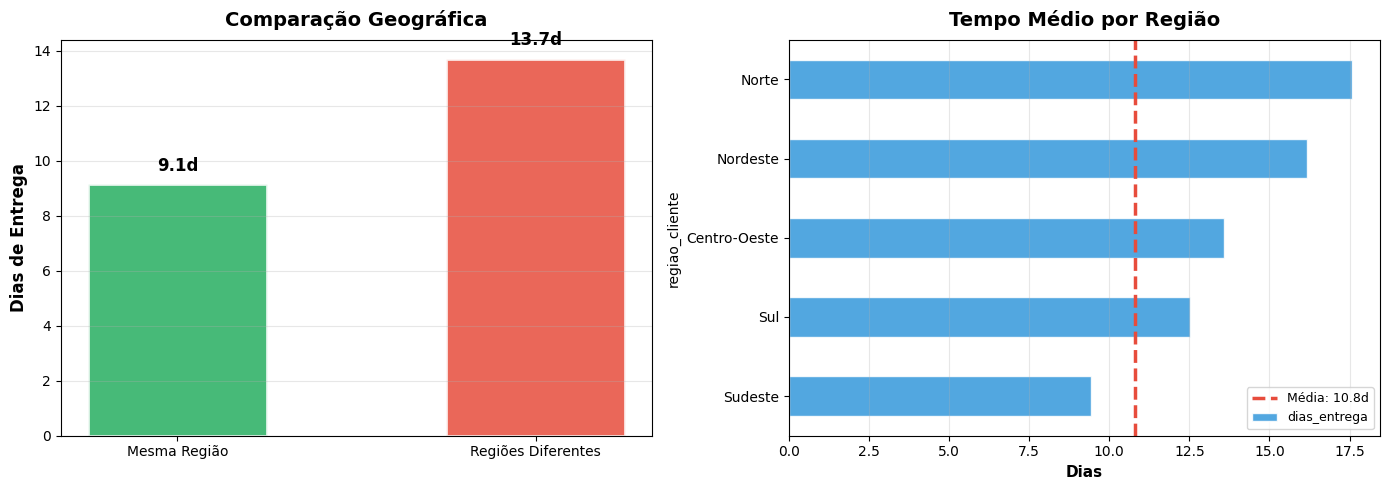

In [51]:
#@title 🔵 Exploração Visual dos Fatores

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ Análise visual dos principais fatores que impactam o tempo de entrega        ║
# ║ CORREÇÕES: mesma_regiao garantida + cores azuis padronizadas                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝


print("\n" + "="*70)
print("📊 EXPLORAÇÃO VISUAL - Fatores de Impacto")
print("="*70 + "\n")

# ═════════════════════════════════════════════════════════════════
# GARANTIR QUE TODAS AS FEATURES NECESSÁRIAS EXISTEM
# ═════════════════════════════════════════════════════════════════

print("🔍 Verificando e criando features necessárias...\n")

# 1. MESMA_REGIAO (CRÍTICO - SEMPRE RECRIAR)
print("   📍 Criando 'mesma_regiao'...")

# Mapear regiões do Brasil
regioes = {
    'SP': 'Sudeste', 'RJ': 'Sudeste', 'MG': 'Sudeste', 'ES': 'Sudeste',
    'PR': 'Sul', 'SC': 'Sul', 'RS': 'Sul',
    'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste', 'DF': 'Centro-Oeste',
    'BA': 'Nordeste', 'CE': 'Nordeste', 'PE': 'Nordeste', 'MA': 'Nordeste',
    'RN': 'Nordeste', 'PB': 'Nordeste', 'SE': 'Nordeste', 'AL': 'Nordeste', 'PI': 'Nordeste',
    'AM': 'Norte', 'PA': 'Norte', 'AC': 'Norte', 'RO': 'Norte',
    'RR': 'Norte', 'AP': 'Norte', 'TO': 'Norte'
}

# Criar colunas de região
base['regiao_cliente'] = base['estado_cliente'].map(regioes)

# Verificar nome correto da coluna do vendedor
col_vendedor = 'estado_vendedor_principal' if 'estado_vendedor_principal' in base.columns else 'estado_vendedor'
base['regiao_vendedor'] = base[col_vendedor].map(regioes)

# Criar feature mesma_regiao
base['mesma_regiao'] = (base['regiao_cliente'] == base['regiao_vendedor']).astype(int)

perc_mesma_regiao = (base['mesma_regiao'].sum() / len(base)) * 100
print(f"      ✅ Criada! {perc_mesma_regiao:.1f}% dos pedidos são intra-regionais\n")

# 2. FEATURES TEMPORAIS
if 'mes' not in base.columns:
    print("   📅 Criando features temporais...")
    base['mes'] = base['data_compra_pedido'].dt.month
    base['dia_semana'] = base['data_compra_pedido'].dt.dayofweek
    base['eh_fds'] = (base['dia_semana'] >= 5).astype(int)
    print("      ✅ Criadas!\n")

# 3. AJUSTAR NOMES DE COLUNAS (para compatibilidade)
if 'categoria_principal' not in base.columns and 'categoria_produto' in base.columns:
    base['categoria_principal'] = base['categoria_produto']
    print("   📦 'categoria_principal' ajustada\n")

if 'peso_total_g' not in base.columns and 'peso_g' in base.columns:
    base['peso_total_g'] = base['peso_g']
    print("   ⚖️ 'peso_total_g' ajustada\n")

if 'valor_total' not in base.columns and 'preco' in base.columns:
    base['valor_total'] = base['preco']
    print("   💰 'valor_total' ajustada\n")

print("✅ Todas as features necessárias estão prontas!\n")

# ═════════════════════════════════════════════════════════════════
# DASHBOARD INICIAL (CORES AZUIS PADRONIZADAS)
# ═════════════════════════════════════════════════════════════════

media_geral = base['dias_entrega'].mean()
mediana_geral = base['dias_entrega'].median()

display(HTML(f"""
<div style='
    background: linear-gradient(135deg, #2E86C1 0%, #1F618D 100%);
    color: white;
    padding: 30px;
    border-radius: 12px;
    margin: 20px 0;
    box-shadow: 0 6px 20px rgba(0,0,0,0.3);
'>
    <h2 style='margin: 0 0 25px 0; text-align:center; font-size: 24px;'>
        📊 BASE FINAL PARA EXPLORAÇÃO
    </h2>
    <div style='display: grid; grid-template-columns: repeat(4, 1fr); gap: 15px;'>
        <div style='background:rgba(255,255,255,0.2); padding:18px; border-radius:8px; text-align:center;'>
            <div style='font-size:13px; opacity:0.9; margin-bottom:5px;'>📦 Pedidos</div>
            <div style='font-size:36px; font-weight:bold;'>{len(base):,}</div>
        </div>
        <div style='background:rgba(255,255,255,0.2); padding:18px; border-radius:8px; text-align:center;'>
            <div style='font-size:13px; opacity:0.9; margin-bottom:5px;'>📋 Features</div>
            <div style='font-size:36px; font-weight:bold;'>{len(base.columns)}</div>
        </div>
        <div style='background:rgba(255,255,255,0.2); padding:18px; border-radius:8px; text-align:center;'>
            <div style='font-size:13px; opacity:0.9; margin-bottom:5px;'>⏱️ Média</div>
            <div style='font-size:36px; font-weight:bold;'>{media_geral:.1f}d</div>
        </div>
        <div style='background:rgba(255,255,255,0.2); padding:18px; border-radius:8px; text-align:center;'>
            <div style='font-size:13px; opacity:0.9; margin-bottom:5px;'>📊 Mediana</div>
            <div style='font-size:36px; font-weight:bold;'>{mediana_geral:.1f}d</div>
        </div>
    </div>
</div>
"""))

# ═════════════════════════════════════════════════════════════════
# 1. IMPACTO GEOGRÁFICO (Principal Fator)
# ═════════════════════════════════════════════════════════════════

print("IMPACTO GEOGRÁFICO\n")

mesma = base[base['mesma_regiao'] == 1]['dias_entrega'].mean()
diferente = base[base['mesma_regiao'] == 0]['dias_entrega'].mean()
diferenca = abs(mesma - diferente)

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras comparativas
regiao_data = [mesma, diferente]
labels = ['Mesma Região', 'Regiões Diferentes']
cores = ['#27AE60', '#E74C3C']
barras = axes[0].bar(labels, regiao_data, color=cores, alpha=0.85, width=0.5, edgecolor='white', linewidth=2)
axes[0].set_ylabel('Dias de Entrega', fontsize=12, fontweight='bold')
axes[0].set_title('Comparação Geográfica', fontsize=14, fontweight='bold', pad=10)
axes[0].grid(axis='y', alpha=0.3)

for bar, val in zip(barras, regiao_data):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val:.1f}d', ha='center', fontweight='bold', fontsize=12)

# Distribuição por região do cliente
base.groupby('regiao_cliente')['dias_entrega'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='#3498DB', alpha=0.85, edgecolor='white'
)
axes[1].axvline(media_geral, color='#E74C3C', linestyle='--', linewidth=2.5,
                label=f'Média: {media_geral:.1f}d')
axes[1].set_xlabel('Dias', fontsize=11, fontweight='bold')
axes[1].set_title('Tempo Médio por Região', fontsize=14, fontweight='bold', pad=10)
axes[1].legend(fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Card de impacto
display(HTML(f"""
<div style='background:#E8F8F5;border-left:5px solid #1ABC9C;color:#0E6251;
    padding:20px;border-radius:8px;margin:20px 0;max-width:600px;'>
    <strong style='font-size:16px;'>🔥 MAIOR IMPACTO</strong><br>
    <div style='margin-top:10px;font-size:14px;'>
        • Mesma região: <strong>{mesma:.1f} dias</strong><br>
        • Regiões diferentes: <strong>{diferente:.1f} dias</strong><br>
        • <strong style='font-size:18px;color:#E74C3C;'>Diferença: {diferenca:.1f} dias ({diferenca/diferente*100:.0f}%)</strong>
    </div>
</div>
"""))

# 🤖 ETAPA 4 — MODELO PREDITIVO

📋 1. Selecionando features para modelagem...

   ✅ Features disponíveis: 7
      • mesma_regiao
      • mes_compra
      • dia_semana_compra
      • trimestre_compra
      • eh_fds
      • qtd_itens
      • valor_total

   ⚠️ Features não encontradas (serão ignoradas): 1
      • peso_total_g

   ✅ Features categóricas: 2
      • estado_cliente
      • regiao_cliente

📊 2. Preparando dataset...

   ✅ Dataset preparado:
      • Registros: 78,551
      • Features: 9
      • Target: dias_entrega
      • Valores nulos: 0

✂️ 3. Dividindo dados...

   ✅ Divisão concluída:
      • Treino: 58,913 registros (75.0%)
      • Teste: 19,638 registros (25.0%)

🤖 4. Treinando modelos...

   🌲 Treinando Random Forest...
      ✅ Random Forest treinado!

   📈 Treinando Gradient Boosting...
      ✅ Gradient Boosting treinado!

📊 5. Avaliando modelos...



,Modelo,MAE (dias),R²,RMSE (dias),MAPE (%)
1,Random Forest,3.89,0.2945,5.01,51.9%
2,Gradient Boosting,3.84,0.3179,4.92,51.7%



✅ TREINAMENTO CONCLUÍDO

📊 Resumo:
   • Modelo vencedor: Gradient Boosting
   • MAE: 3.84 dias
   • R²: 0.318
   • Features utilizadas: 9
   • Dados de treino: 58,913
   • Dados de teste: 19,638

📊 GERANDO GRÁFICOS DE ANÁLISE

📊 1/4 - Importância das Features...



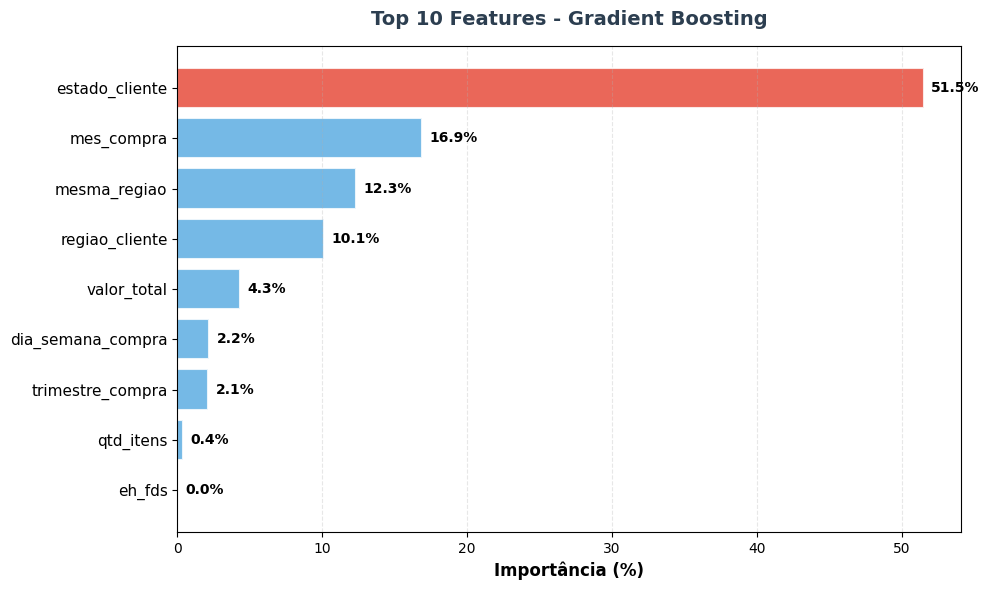




📊 2/4 - Real vs Previsto...



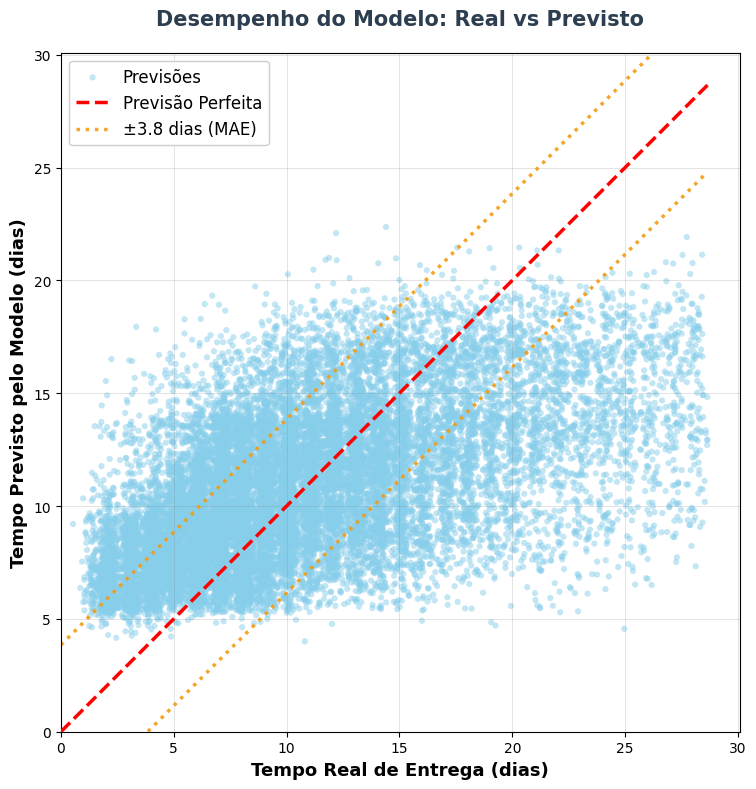




📊 3/4 - Distribuição dos Erros...



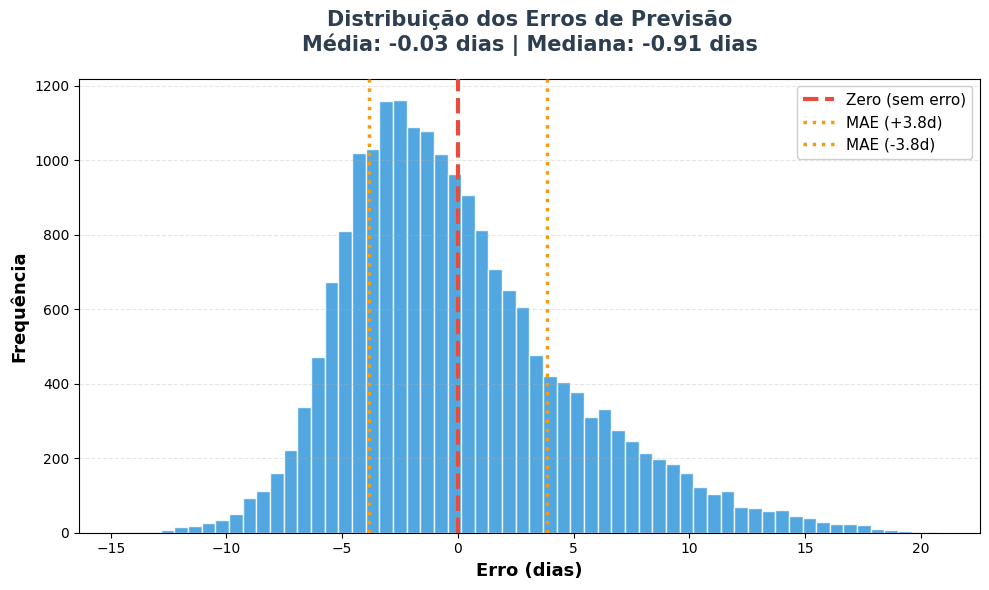




📊 4/4 - Resumo com Métricas...



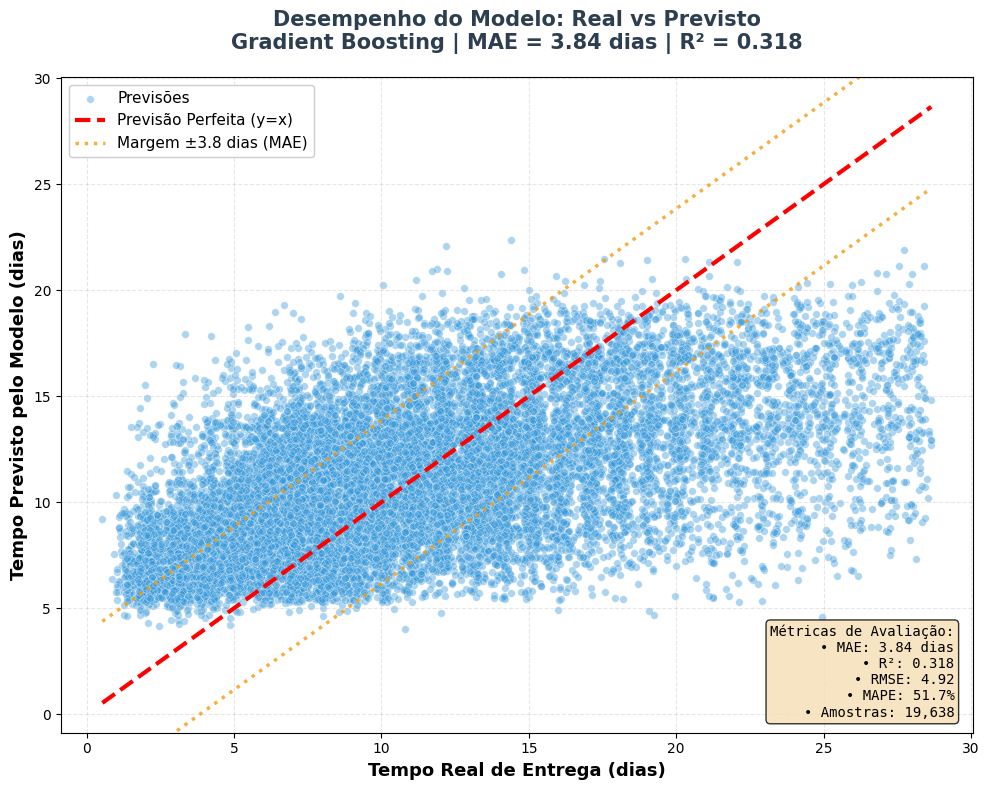


📊 ANÁLISE DA QUALIDADE DAS PREVISÕES

✅ Precisão do Modelo:
   • 58.7% das previsões erram menos que ±3.8 dias
   • 89.4% das previsões erram menos que ±7.7 dias

📈 Distribuição dos Erros:
   • Erro médio: -0.03 dias
   • Erro mediano: -0.91 dias
   • Desvio padrão: 4.92 dias

🎯 Recomendação para uso prático:
   • Margem de segurança sugerida: ±6 a ±8 dias
   • Isso garante 89% de acerto nas estimativas



In [52]:
#@title 🔵 Modelagem

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║ Prepara dados, treina modelos, avalia desempenho e gera gráficos finais     ║
# ║ VERSÃO INTEGRADA - tudo em um único bloco                                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ═════════════════════════════════════════════════════════════════
# 1. PREPARAÇÃO DOS DADOS
# ═════════════════════════════════════════════════════════════════

print("📋 1. Selecionando features para modelagem...\n")

# Target
target = 'dias_entrega'

# Features candidatas
features_candidatas = [
    'mesma_regiao',
    'mes_compra',
    'dia_semana_compra',
    'trimestre_compra',
    'eh_fds',
    'qtd_itens',
    'peso_total_g',
    'valor_total'
]

# Verificar quais features existem
features_disponiveis = [f for f in features_candidatas if f in base.columns]
features_faltando = [f for f in features_candidatas if f not in base.columns]

print(f"   ✅ Features disponíveis: {len(features_disponiveis)}")
for f in features_disponiveis:
    print(f"      • {f}")

if features_faltando:
    print(f"\n   ⚠️ Features não encontradas (serão ignoradas): {len(features_faltando)}")
    for f in features_faltando:
        print(f"      • {f}")

# Adicionar features categóricas
categoricas = []
if 'estado_cliente' in base.columns:
    categoricas.append('estado_cliente')
if 'regiao_cliente' in base.columns:
    categoricas.append('regiao_cliente')
if 'categoria_principal' in base.columns:
    top_cat = base['categoria_principal'].value_counts().head(15).index
    base['categoria_top15'] = base['categoria_principal'].apply(
        lambda x: x if x in top_cat else 'Outros'
    )
    categoricas.append('categoria_top15')

print(f"\n   ✅ Features categóricas: {len(categoricas)}")
for c in categoricas:
    print(f"      • {c}")

# ═════════════════════════════════════════════════════════════════
# 2. CODIFICAR CATEGÓRICAS E PREPARAR DATASET
# ═════════════════════════════════════════════════════════════════

print(f"\n📊 2. Preparando dataset...\n")

X = base[features_disponiveis + categoricas].copy()
y = base[target].copy()

# Label Encoding
le_dict = {}
for col in categoricas:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    le_dict[col] = le

# Tratar nulos
for col in X.columns:
    if X[col].isnull().sum() > 0:
        if X[col].dtype in ['float64', 'int64']:
            X[col].fillna(X[col].median(), inplace=True)
        else:
            X[col].fillna(X[col].mode()[0], inplace=True)

mask_valido = y.notna()
X = X[mask_valido]
y = y[mask_valido]

print(f"   ✅ Dataset preparado:")
print(f"      • Registros: {len(X):,}")
print(f"      • Features: {len(X.columns)}")
print(f"      • Target: {target}")
print(f"      • Valores nulos: {X.isnull().sum().sum()}")

# ═════════════════════════════════════════════════════════════════
# 3. DIVISÃO TREINO/TESTE
# ═════════════════════════════════════════════════════════════════

print(f"\n✂️ 3. Dividindo dados...\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print(f"   ✅ Divisão concluída:")
print(f"      • Treino: {len(X_train):,} registros ({len(X_train)/len(X)*100:.1f}%)")
print(f"      • Teste: {len(X_test):,} registros ({len(X_test)/len(X)*100:.1f}%)")

features_selecionadas = list(X.columns)

# ═════════════════════════════════════════════════════════════════
# 4. TREINAMENTO DOS MODELOS
# ═════════════════════════════════════════════════════════════════

print(f"\n🤖 4. Treinando modelos...\n")

# Random Forest
print("   🌲 Treinando Random Forest...")
modelo_rf = RandomForestRegressor(
    n_estimators=100, max_depth=15, min_samples_split=5,
    random_state=42, n_jobs=-1, verbose=0
)
modelo_rf.fit(X_train, y_train)
print("      ✅ Random Forest treinado!")

# Gradient Boosting
print("\n   📈 Treinando Gradient Boosting...")
modelo_gb = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=5,
    random_state=42, verbose=0
)
modelo_gb.fit(X_train, y_train)
print("      ✅ Gradient Boosting treinado!")

# ═════════════════════════════════════════════════════════════════
# 5. AVALIAR MODELOS
# ═════════════════════════════════════════════════════════════════

print(f"\n📊 5. Avaliando modelos...\n")

def avaliar_modelo(modelo, X_test, y_test, nome):
    y_pred = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    mask = y_test > 0.5
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_test[mask] - y_pred[mask]) / y_test[mask])) * 100
    else:
        mape = np.nan

    return {
        'Modelo': nome,
        'MAE (dias)': f"{mae:.2f}",
        'R²': f"{r2:.4f}",
        'RMSE (dias)': f"{rmse:.2f}",
        'MAPE (%)': f"{mape:.1f}%" if not np.isnan(mape) else "N/A",
        'mae_num': mae,
        'r2_num': r2,
        'y_pred': y_pred
    }

resultado_rf = avaliar_modelo(modelo_rf, X_test, y_test, "Random Forest")
resultado_gb = avaliar_modelo(modelo_gb, X_test, y_test, "Gradient Boosting")

resultados = pd.DataFrame([resultado_rf, resultado_gb])
resultados_display = resultados[['Modelo', 'MAE (dias)', 'R²', 'RMSE (dias)', 'MAPE (%)']].copy()
resultados_display.index = range(1, len(resultados_display) + 1)

display(estilo_tabela(resultados_display, "📊 Comparação de Modelos (Métrica Principal: MAE)"))

# ═════════════════════════════════════════════════════════════════
# 6. SELECIONAR MELHOR MODELO
# ═════════════════════════════════════════════════════════════════

melhor_idx = resultados['mae_num'].idxmin()
melhor_modelo_nome = resultados.loc[melhor_idx, 'Modelo']
melhor_modelo = modelo_rf if melhor_modelo_nome == "Random Forest" else modelo_gb
melhor_mae = resultados.loc[melhor_idx, 'mae_num']
melhor_r2 = resultados.loc[melhor_idx, 'r2_num']
melhor_pred = resultados.loc[melhor_idx, 'y_pred']

# Dashboard
display(HTML(f"""
<div style='
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
    color: white;
    padding: 30px;
    border-radius: 12px;
    margin: 30px 0;
    box-shadow: 0 4px 15px rgba(0,0,0,0.2);
'>
    <h3 style='margin: 0 0 25px 0; font-size: 22px; text-align:center;'>
        🏆 Melhor Modelo: {melhor_modelo_nome}
    </h3>
    <div style='display: grid; grid-template-columns: repeat(2, 1fr); gap: 20px;'>
        <div style='background:rgba(255,255,255,0.15); padding:20px; border-radius:8px; text-align:center;'>
            <div style='font-size: 14px; opacity: 0.9; margin-bottom:8px;'>🎯 MAE (Métrica Principal)</div>
            <div style='font-size: 36px; font-weight: bold;'>{melhor_mae:.2f}</div>
            <div style='font-size: 12px; opacity: 0.8; margin-top:5px;'>dias de erro médio absoluto</div>
        </div>
        <div style='background:rgba(255,255,255,0.15); padding:20px; border-radius:8px; text-align:center;'>
            <div style='font-size: 14px; opacity: 0.9; margin-bottom:8px;'>📊 R² Score</div>
            <div style='font-size: 36px; font-weight: bold;'>{melhor_r2:.3f}</div>
            <div style='font-size: 12px; opacity: 0.8; margin-top:5px;'>Explica {melhor_r2*100:.1f}% da variação</div>
        </div>
        <div style='background:rgba(255,255,255,0.15); padding:20px; border-radius:8px; text-align:center;'>
            <div style='font-size: 14px; opacity: 0.9; margin-bottom:8px;'>📐 RMSE</div>
            <div style='font-size: 36px; font-weight: bold;'>{resultados.loc[melhor_idx, "RMSE (dias)"]}</div>
            <div style='font-size: 12px; opacity: 0.8; margin-top:5px;'>dias (penaliza erros grandes)</div>
        </div>
        <div style='background:rgba(255,255,255,0.15); padding:20px; border-radius:8px; text-align:center;'>
            <div style='font-size: 14px; opacity: 0.9; margin-bottom:8px;'>📊 MAPE</div>
            <div style='font-size: 36px; font-weight: bold;'>{resultados.loc[melhor_idx, "MAPE (%)"]}</div>
            <div style='font-size: 12px; opacity: 0.8; margin-top:5px;'>erro percentual médio</div>
        </div>
    </div>
    <div style='background:rgba(39,174,96,0.3); padding:15px; border-radius:8px; margin-top:20px; text-align:center;'>
        <strong style='font-size:14px;'>✅ Modelo selecionado pelo menor MAE</strong><br>
        <span style='font-size:12px;'>Métrica mais direta para prever tempo de entrega em dias</span>
    </div>
</div>
"""))

print("\n" + "="*70)
print("✅ TREINAMENTO CONCLUÍDO")
print("="*70)
print(f"\n📊 Resumo:")
print(f"   • Modelo vencedor: {melhor_modelo_nome}")
print(f"   • MAE: {melhor_mae:.2f} dias")
print(f"   • R²: {melhor_r2:.3f}")
print(f"   • Features utilizadas: {len(features_selecionadas)}")
print(f"   • Dados de treino: {len(X_train):,}")
print(f"   • Dados de teste: {len(X_test):,}")

# ═════════════════════════════════════════════════════════════════
# 7. GRÁFICOS DE ANÁLISE
# ═════════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("📊 GERANDO GRÁFICOS DE ANÁLISE")
print("="*70 + "\n")

# GRÁFICO 1: Importância das Features
if hasattr(melhor_modelo, 'feature_importances_'):
    print("📊 1/4 - Importância das Features...\n")

    importancias = melhor_modelo.feature_importances_ * 100
    importancia_df = pd.DataFrame({
        'Feature': features_selecionadas,
        'Importância': importancias
    }).sort_values('Importância', ascending=True).tail(10)

    fig, ax = plt.subplots(figsize=(10, 6))
    cores = ['#E74C3C' if i == len(importancia_df)-1 else '#5DADE2'
             for i in range(len(importancia_df))]

    barras = ax.barh(range(len(importancia_df)), importancia_df['Importância'],
                     color=cores, alpha=0.85, edgecolor='white', linewidth=1.5)

    for i, (idx, row) in enumerate(importancia_df.iterrows()):
        ax.text(row['Importância'] + 0.5, i, f"{row['Importância']:.1f}%",
                va='center', fontsize=10, fontweight='bold')

    ax.set_yticks(range(len(importancia_df)))
    ax.set_yticklabels(importancia_df['Feature'], fontsize=11)
    ax.set_xlabel('Importância (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'Top 10 Features - {melhor_modelo_nome}',
                 fontsize=14, fontweight='bold', color='#2C3E50', pad=15)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()
    print("\n" * 2)

# GRÁFICO 2: Real vs Previsto (com linhas MAE)
print("📊 2/4 - Real vs Previsto...\n")

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(y_test, melhor_pred, alpha=0.5, s=20, color='#87CEEB',
           edgecolors='none', label='Previsões')

min_val = 0
max_val = max(y_test.max(), melhor_pred.max())

ax.plot([min_val, max_val], [min_val, max_val],
        'r--', linewidth=2.5, label='Previsão Perfeita', zorder=10)
ax.plot([min_val, max_val], [min_val + melhor_mae, max_val + melhor_mae],
        color='#F39C12', linestyle=':', linewidth=2.5, alpha=0.9,
        label=f'±{melhor_mae:.1f} dias (MAE)')
ax.plot([min_val, max_val], [min_val - melhor_mae, max_val - melhor_mae],
        color='#F39C12', linestyle=':', linewidth=2.5, alpha=0.9)

ax.set_xlabel("Tempo Real de Entrega (dias)", fontsize=13, fontweight='bold')
ax.set_ylabel("Tempo Previsto pelo Modelo (dias)", fontsize=13, fontweight='bold')
ax.set_title("Desempenho do Modelo: Real vs Previsto",
             fontsize=15, fontweight='bold', color='#2C3E50', pad=20)
ax.grid(alpha=0.3, linestyle='-', linewidth=0.5, color='gray')
ax.legend(fontsize=12, loc='upper left', framealpha=0.95)
ax.set_xlim(min_val, max_val * 1.05)
ax.set_ylim(min_val, max_val * 1.05)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()
print("\n" * 2)

# GRÁFICO 3: Distribuição dos Erros
print("📊 3/4 - Distribuição dos Erros...\n")

erros = y_test - melhor_pred

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(erros, bins=60, color='#3498DB', alpha=0.85, edgecolor='white', linewidth=1)
ax.axvline(0, color='#E74C3C', linestyle='--', linewidth=3,
           label='Zero (sem erro)', zorder=10)
ax.axvline(melhor_mae, color='#F39C12', linestyle=':', linewidth=2.5,
           label=f'MAE (+{melhor_mae:.1f}d)', zorder=10)
ax.axvline(-melhor_mae, color='#F39C12', linestyle=':', linewidth=2.5,
           label=f'MAE (-{melhor_mae:.1f}d)', zorder=10)

ax.set_xlabel("Erro (dias)", fontsize=13, fontweight='bold')
ax.set_ylabel("Frequência", fontsize=13, fontweight='bold')
ax.set_title(f"Distribuição dos Erros de Previsão\nMédia: {erros.mean():.2f} dias | Mediana: {erros.median():.2f} dias",
             fontsize=15, fontweight='bold', color='#2C3E50', pad=20)
ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(fontsize=11, loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.show()
print("\n" * 2)

# GRÁFICO 4: Real vs Previsto (com métricas)
print("📊 4/4 - Resumo com Métricas...\n")

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(y_test, melhor_pred, alpha=0.4, s=30, color='#3498DB',
           edgecolors='white', linewidth=0.5, label='Previsões')

min_val = min(y_test.min(), melhor_pred.min())
max_val = max(y_test.max(), melhor_pred.max())

ax.plot([min_val, max_val], [min_val, max_val],
        'r--', linewidth=3, label='Previsão Perfeita (y=x)', zorder=10)
ax.plot([min_val, max_val], [min_val + melhor_mae, max_val + melhor_mae],
        color='#F39C12', linestyle=':', linewidth=2.5, alpha=0.8,
        label=f'Margem ±{melhor_mae:.1f} dias (MAE)')
ax.plot([min_val, max_val], [min_val - melhor_mae, max_val - melhor_mae],
        color='#F39C12', linestyle=':', linewidth=2.5, alpha=0.8)

ax.set_xlabel("Tempo Real de Entrega (dias)", fontsize=13, fontweight='bold')
ax.set_ylabel("Tempo Previsto pelo Modelo (dias)", fontsize=13, fontweight='bold')
ax.set_title(f"Desempenho do Modelo: Real vs Previsto\n{melhor_modelo_nome} | MAE = {melhor_mae:.2f} dias | R² = {melhor_r2:.3f}",
             fontsize=15, fontweight='bold', color='#2C3E50', pad=20)
ax.grid(alpha=0.3, linestyle='--', linewidth=0.8)
ax.legend(fontsize=11, loc='upper left', framealpha=0.95)

margem = (max_val - min_val) * 0.05
ax.set_xlim(min_val - margem, max_val + margem)
ax.set_ylim(min_val - margem, max_val + margem)

texto_metricas = f"""Métricas de Avaliação:
• MAE: {melhor_mae:.2f} dias
• R²: {melhor_r2:.3f}
• RMSE: {resultados.loc[melhor_idx, 'RMSE (dias)']}
• MAPE: {resultados.loc[melhor_idx, 'MAPE (%)']}
• Amostras: {len(y_test):,}"""

ax.text(0.98, 0.02, texto_metricas, transform=ax.transAxes, fontsize=10,
        verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        family='monospace')

plt.tight_layout()
plt.show()

# Análise Final
dentro_mae = ((erros >= -melhor_mae) & (erros <= melhor_mae)).sum()
dentro_2mae = ((erros >= -2*melhor_mae) & (erros <= 2*melhor_mae)).sum()
perc_dentro_mae = (dentro_mae / len(erros)) * 100
perc_dentro_2mae = (dentro_2mae / len(erros)) * 100

print("\n" + "="*70)
print("📊 ANÁLISE DA QUALIDADE DAS PREVISÕES")
print("="*70)
print(f"\n✅ Precisão do Modelo:")
print(f"   • {perc_dentro_mae:.1f}% das previsões erram menos que ±{melhor_mae:.1f} dias")
print(f"   • {perc_dentro_2mae:.1f}% das previsões erram menos que ±{melhor_mae*2:.1f} dias")
print(f"\n📈 Distribuição dos Erros:")
print(f"   • Erro médio: {erros.mean():.2f} dias")
print(f"   • Erro mediano: {erros.median():.2f} dias")
print(f"   • Desvio padrão: {erros.std():.2f} dias")
print(f"\n🎯 Recomendação para uso prático:")
print(f"   • Margem de segurança sugerida: ±{melhor_mae*1.5:.0f} a ±{melhor_mae*2:.0f} dias")
print(f"   • Isso garante {perc_dentro_2mae:.0f}% de acerto nas estimativas")
print("\n" + "="*70)